In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

TODO:
1) X - Save Models
2) train from script
3) Subset fragment lengths
4) explore variance of counts
5) Add jitter
6) add count head
7) Don't filter out duplicates in frag h5 creation
8) Only fit forward starts and reverse ends

In [2]:
import pysam

In [3]:
FASTA_PATH = "/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38/GRCh38.p12.genome.fa.gz"

In [4]:
import os
import pandas as pd
from fragmentomics_tools.dataframe import RegionDataFrame

def build_ctcf_binding_sites():
    ### load and merge all of the binding sites #######################################################################
    base_dir = "/scratch/ctcf_analysis/CTCF/cell_type_merged"
    index_cols = ['contig', 'start', 'stop', 'strand']
    dfs = []
    for fname in os.listdir(base_dir):
        # extract the biosample type from the filename
        cell_type = fname.split('.')[1]
        # load the data into a region dataframe
        df = pd.read_table(os.path.join(base_dir, fname))
        # subset the dataframe by the binding site locations
        df = df[['contig', 'start', 'stop', 'strand', 'tf_top_score']].set_index(index_cols)
        # rename the score column to the biosample_type
        df = df.rename(columns={'tf_top_score': cell_type})
        df = df.sort_values(df.columns[0], ascending=False).head(20000).sort_index()
        dfs.append(df)

    # merge everything
    df = dfs[0]
    for i in range(1, len(dfs)): 
        df = df.join(dfs[i], how='outer')
        
    # binarize based upon peak presence
    df = pd.DataFrame(df.fillna(0).sort_index())
    df = (df > 1e-6).astype(int)
    
    # neutrophils look weird
    df = df.drop(columns='neutrophil')

    return RegionDataFrame(df.reset_index(), ref='hg38')

In [5]:
ctcf_rdf = build_ctcf_binding_sites()

In [6]:
ctcf_rdf

,contig,start,stop,strand,"CD8-positive,_alpha-beta_T_cell",mucosa_of_descending_colon,B_cell,neural_cell,osteoblast,sigmoid_colon,natural_killer_cell,transverse_colon,stomach,dorsolateral_prefrontal_cortex,CD14-positive_monocyte,neural_crest_cell,neural_progenitor_cell
0,chr1,91419,91436,+,0,0,1,1,0,0,0,0,0,0,0,0,0
1,chr1,181743,181760,-,1,0,1,0,0,1,1,1,0,1,1,1,1
2,chr1,267998,268015,+,1,1,1,1,0,1,1,1,1,1,1,0,0
3,chr1,586152,586169,+,1,0,1,0,0,1,0,1,0,1,1,0,0
4,chr1,609382,609399,+,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48032,chrX,155651425,155651442,-,0,0,1,0,1,0,1,0,0,0,1,1,0
48033,chrX,155662512,155662529,+,0,0,1,0,0,0,0,1,0,0,0,0,0
48034,chrX,155820326,155820343,-,1,0,0,1,0,1,1,0,1,1,1,0,0
48035,chrX,155967078,155967095,+,1,0,1,0,1,0,0,0,0,1,0,1,1


In [7]:
import itertools
from typing import Optional # , Dict, Type, Union, Tuple, List

from typing import Dict, Optional, List, Set, Type, Union

import numpy
import pandas
import torch
from torch import Tensor
import torch.optim as optim
from torch.nn.modules.loss import _Loss

import os
import torch
from torch import optim, nn, utils, Tensor
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import lightning as L
from fragmentomics_tools.sequence import one_hot_encode_sequences


import matplotlib.pyplot as plt

from fragmentomics_tools.dataframe import DataFrameBase
from fragmentomics_tools.region import Region

# from ravel.learn.functional_genomics.losses import MultinomialNLLLoss

from scipy.stats import multinomial
from scipy.special import softmax

def calculate_start_and_stop_from_jitter(
    input_length, output_length, jitter_value, strand: Optional[str] = None
):
    """
    Calculates the new start and stop of a region given some +/- jitter value and output length
    Importantly, this is only defined on input / output lengths of the same parity:
        allowed: (even, even), (odd, odd)
        disallowed: (even, odd), (odd, even)
    :param input_length: length of input region
    :param output_length: desired output length of region
    :param jitter_value: a +/- value from the center of the input region by which to shift window
    :param strand: Optional strand, if not supplied this will default to assuming the user wants + strand.
    :return: coordinates for, e.g., slicing
    """
    if input_length < output_length + numpy.abs(jitter_value):
        raise ValueError(
            f"input array is not wide enough to allow for an output of"
            f" length {output_length} with jitter_value of {jitter_value}."
        )

    resize_start = Region.get_resize_start(
        start=0, current_size=input_length, new_size=output_length, strand=strand
    )
    jitter_start = resize_start + jitter_value
    jitter_stop = jitter_start + output_length
    return jitter_start, jitter_stop

def jitter_matrix(input_arr, jitter_value, output_length, strand: Optional[str] = None):
    input_length = input_arr.shape[-1]

    if round(jitter_value) != jitter_value:
        raise ValueError(f"jitter_range must be a whole number, received {jitter_value}.")

    if input_length < output_length + numpy.abs(jitter_value):
        raise ValueError(
            f"input array is not wide enough to allow for an output of"
            f" length {output_length} with jitter_value of {jitter_value}."
        )

    new_start, new_stop = calculate_start_and_stop_from_jitter(
        input_length=input_length, output_length=output_length, jitter_value=jitter_value, strand=strand
    )
    assert new_stop - new_start == output_length, (output_length, new_stop, new_start)
    assert new_start >= 0, new_start
    assert new_stop <= input_length, (new_stop, input_length)

    if isinstance(input_arr, numpy.ndarray) or isinstance(input_arr, torch.Tensor):
        jittered_output = input_arr[..., new_start:new_stop]
    elif scipy.sparse.issparse(input_arr):
        indices = numpy.where((input_arr.col < new_stop) & (input_arr.col >= new_start))[0]

        jittered_output = coo_matrix(
            (
                numpy.ones(len(indices)),
                (input_arr.row[indices], input_arr.col[indices] - new_start),
            ),
            shape=[input_arr.shape[0], output_length],
            dtype=input_arr.dtype,
        )
    else:
        raise TypeError(f"input_arr type {type(input_arr)} is invalid.")

    return jittered_output

class MultinomialNLLLoss(_Loss):
    def __init__(
        self,
        size_average=None,
        reduce=None,
        is_probs=False,
        reduction: str = "mean",
        scale_loss_to_d: bool = False,
    ) -> None:
        """Multinomial Negative Log Likelihood Loss

        :param size_average: (bool, optional) Deprecated (see :attr:`reduction`). By default,
            the losses are averaged over each loss element in the batch. Note that for
            some losses, there are multiple elements per sample. If the field :attr:`size_average`
            is set to ``False``, the losses are instead summed for each minibatch. Ignored
            when :attr:`reduce` is ``False``. Default: ``True``
        :param reduce: (bool, optional) Deprecated (see :attr:`reduction`). By default, the
            losses are averaged or summed over observations for each minibatch depending
            on :attr:`size_average`. When :attr:`reduce` is ``False``, returns a loss per
            batch element instead and ignores :attr:`size_average`. Default: ``True``
        :param reduction:  (string, optional) Specifies the reduction to apply to the output:
            ``'none'`` | ``'mean'`` | ``'sum'``. ``'none'``: no reduction will be applied,
            ``'mean'``: the sum of the output will be divided by the number of
            elements in the output, ``'sum'``: the output will be summed. Note: :attr:`size_average`
            and :attr:`reduce` are in the process of being deprecated, and in the meantime,
            specifying either of those two args will override :attr:`reduction`. Default: ``'mean'``
        :param scale_loss_to_d: if true, loss is scaled by 1/sqrt(dimension)
        :param is_probs: (bool). Set to true if you have the model output probabilities rather than
            logits. This should usually be false.
        """
        super().__init__(size_average, reduce, reduction)
        self.scale_loss_to_d = scale_loss_to_d
        self.is_probs = is_probs

    def forward(self, input: Tensor, target: Tensor) -> Tensor:
        dims = input.shape
        # *dims[:2] is batch, channel
        inputs_flat = input.contiguous().view(*dims[:2], -1)
        target_flat = target.contiguous().view(*dims[:2], -1)
        if self.is_probs:
            # Note total_count is not used when calculating log_prob, and for log_prob,
            # validate_args is just a check that throws errors if the sum doesn't match total_count
            dist = torch.distributions.Multinomial(probs=inputs_flat, validate_args=False)
        else:
            dist = torch.distributions.Multinomial(logits=inputs_flat, validate_args=False)

        if self.scale_loss_to_d:
            d = inputs_flat.shape[-1]
            scale = 1.0 / sqrt(d)
        else:
            scale = 1.0
        with torch.no_grad():
            min_counts, _ = target_flat.min(dim=-1)
            min_count = min_counts.min()
            if min_count < 0:
                raise ValueError(f"Saw a count < 0: {min_count}, all mins:{min_counts}")

        nll = -dist.log_prob(target_flat) * scale

        if self.reduction == "mean":
            return nll.mean()
        elif self.reduction == "sum":
            return nll.sum()
        elif self.reduction == "none":
            return nll
        else:
            raise NotImplementedError(f"Reduction {self.reduction} is not implemented.")


class SpatialDropout(nn.Module):
    def __init__(self, p=0.2):
        """TLDR; Full Channel Dropout in ND. This replicates keras SpatialDropout1D but with the pytorch expected
            channel ordering. See https://discuss.pytorch.org/t/spatial-dropout-in-pytorch/21400/4
            Basically this will drop out full channels, or leave them in tact.
        :param p: dropout fraction, also note that the non-dropped values are filled with 1/p as in pytorch.
        """
        super().__init__()
        self.p = p
        self.do2 = nn.Dropout2d(p)

    def forward(self, x):
        if self.training:
            ori_shape = x.shape
            x = x.view(*ori_shape[:2], -1)  # flatten everything beyond the channel dimension
            x = x.permute(0, 2, 1)
            x = self.do2(x)
            x = x.permute(0, 2, 1)
            x = x.view(
                ori_shape
            )  # restore the feature shape, pixels will have been dropped out across channels.
        return x


class ResNetDilatedBlock(nn.Module):
    def __init__(
        self,
        input_channels: int = 64,
        profile_kernel_size: int = 20,
        dilation_rate: int = 1,
        activation: Type[nn.Module] = nn.ReLU,
        activation_post_sum: bool = False,
        skip_batchnorm: bool = False,
        preact_residual_normalization: bool = False,
        padding: Union[str, int] = "same",
    ):
        """A Dilated Convolutional Block with user defined activation and padding so input size == output size.
            x is added back to the output after passing through the dilated convolution layer.

            This Module does not change the inputs dimensionality.

        :param input_channels: The number of filters (in the conv in filters == out filters).
        :param profile_kernel_size: Profile kernel size.
            This should be odd unless the dilation rate is even, then it can be either.
        :param dilation_rate: rate of dilation
        :param activation: module of desired activation function. Defaults to nn.ReLU.
        :param preact_residual_normalization: Apply a pre-activation layer (recommended) to limit
            accumulation of variance in deeper networks. See:
            https://iclr-blog-track.github.io/2022/03/25/unnormalized-resnets/#moment-control
        :param activation_post_sum: Apply activation after adding x back in (the residual connection). Default=True
            which is what pytorch does in it's resnet implementation.
        """
        super().__init__()
        assert (
            profile_kernel_size % 2 == 1 or dilation_rate % 2 == 0
        ), f"Please provide an odd kernel size, you gave {profile_kernel_size}"
        self.activation_post_sum = activation_post_sum
        self.conv1 = nn.Conv1d(
            in_channels=input_channels,
            out_channels=input_channels,
            stride=1,
            kernel_size=profile_kernel_size,
            padding=(dilation_rate * (profile_kernel_size - 1)) // 2 if padding == "same" else padding,
            dilation=dilation_rate,
        )
        self.preact_residual_normalization = preact_residual_normalization
        if self.preact_residual_normalization:
            self.bn_preact = nn.BatchNorm1d(input_channels)
        else:
            self.bn_preact = None
        self.bn = nn.BatchNorm1d(input_channels)
        self.skip_batchnorm = skip_batchnorm
        self.activation = activation()

    def forward(self, x: torch.Tensor):
        """
        :param x: torch.Tensor
        :return: torch.Tensor of the same shape as input.
        """
        if self.preact_residual_normalization:
            # https://iclr-blog-track.github.io/2022/03/25/unnormalized-resnets/#moment-control
            # where preact is later defined as nn.Sequential([norm_layer(inplanes), nn.ReLU()])
            # in PreResidualBottleneck. The alpha/beta terms are stored inside of the norm_layer.
            assert self.bn_preact is not None
            x = self.activation(self.bn_preact(x))
        out = self.conv1(x)
        if not self.skip_batchnorm:
            out = self.bn(out)
        if out.shape[-1] < x.shape[-1]:
            x = jitter_matrix(x, jitter_value=0, output_length=out.shape[-1])
        if self.activation_post_sum:
            # default pytorch method
            resid = out + x
            return self.activation(resid)
        else:
            out = self.activation(out)
            return out + x



WARNING	2024-03-28 11:46:22,449	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c104warnERKNS_7WarningE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



In [240]:
from fragmentomics_tools.plot.tracks import Tracks, StrandSplitCoverageTrack, VectorTrack, GeneTrack, BedTrack
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays


# define the LightningModule
class BackgroundModelModule(L.LightningModule):
    def get_model(self):
        initial_layer = nn.Sequential(
            nn.Conv1d(
                in_channels=self.model_params['input_channels'],
                out_channels=self.model_params['n_kernels'],  # one per strand so will be doubled
                kernel_size=self.model_params['kernel_size'],
                padding=0,
            ),
            nn.LeakyReLU(),
            SpatialDropout(p=self.model_params['dropout']),
        )
        
        res_net_layers = []
        res_net_layers.extend(
            [
                ResNetDilatedBlock(
                    dilation_rate=2**i,
                    input_channels=self.model_params['n_kernels'],
                    activation=nn.LeakyReLU,
                    profile_kernel_size=self.model_params['kernel_size'],
                    activation_post_sum=True,
                    skip_batchnorm=True,
                    preact_residual_normalization=False,
                    padding=0, # (self.model_params['kernel_size']-1),
                )
                for i in range(1, self.model_params['num_residual_layers']+1)
            ]
        )
        
        final_layer = nn.Conv1d(
            in_channels=self.model_params['n_kernels'],
            out_channels=self.output_tracks_multiplier*len(self.output_columns),
            kernel_size=(self.model_params['kernel_size'],),
            padding=0,
        )
        
        layers = [initial_layer] + res_net_layers + [final_layer]

        return nn.Sequential(*layers)

    def calc_input_region_size(self, output_region_size):
        return output_region_size \
        + 2*(self.model_params['kernel_size']-1)  \
        + sum([
            (self.model_params['kernel_size']-1)*(2**i) 
            for i in range(1, self.model_params['num_residual_layers']+1)
        ])

    def predict_region(self, region, prbs=True):
        assert False
        if self.model_params['loss'] == 'multinomial':
            columns = [x + "_hat" for x in self.output_columns]
        elif self.model_params['loss'] == 'negative_binomial':
            columns = [x + "_hat_logits" for x in self.output_columns] + [x + "_hat_total_count" for x in self.output_columns]
        else:
            raise ValueError(f"Unrecognized loss '{self.loss}'")
        
        output_length = region.length
        input_length = self.calc_input_region_size(output_length)
        with pysam.Fastafile(FASTA_PATH) as fasta:
            seq = region.resize(input_length).get_sequence(fasta).decode()
        one_hot_seq = one_hot_encode_sequences([seq.encode(),])[0, :, :].T
        one_hot_seq = torch.Tensor(one_hot_seq)[None, :]
        pred = self.model(one_hot_seq).cpu().detach().numpy()[0].squeeze().astype("float64")
    
        if prbs:
            if self.model_params['loss'] == 'multinomial': 
                pred = softmax(pred, axis=1)
            elif self.model_params['loss'] == 'negative_binomial':
                columns = [x + "_hat" for x in self.output_columns]
                new_pred = []
                for column_i in range(len(self.output_columns)):
                    logits = torch.Tensor(pred[column_i])
                    total_count = torch.Tensor(pred[column_i + len(self.output_columns)])
                    new_pred.append(((1 + 20*torch.sigmoid(total_count)) * torch.exp(logits)).numpy())
                pred = softmax(numpy.vstack(new_pred))
            else:
                assert False, "UNREACHABLE"
    
        rv = pd.DataFrame(pred).T.rename(columns=dict(zip(range(4), columns)))
        return rv

    def predict_from_region_fragment_array(self, rfa, prbs=True):
        assert False
        targets = pd.DataFrame(FragmentEndpointsDataset.get_targets_from_region_fragment_array(rfa, self.output_columns).cpu().detach().T).rename(columns=dict(enumerate(self.output_columns)))
        pred = self.predict_region(rfa.region, prbs=prbs)
        pred = (pred * (targets.max().values/pred.max().values))
        # pred = (pred * (targets.sum().values))
        return BackgroundModelPredictionsDataFrame(pd.concat([targets, pred], axis=1), region=rfa.region)

    def save(self, path):
        state_dict = self.model.state_dict()
        state_dict["model_params"] = self.model_params
        torch.save(state_dict, path)

    @classmethod
    def load(cls, path):
        state_dict = torch.load(path)
        rv = cls(**state_dict.pop('model_params'))
        rv.model.load_state_dict(state_dict)
        return rv

    def __init__(
        self, 
        dropout = 0.15,
        input_channels = 4,
        output_columns = ['fwd_start_counts', 'bkwd_start_counts', 'fwd_stop_counts', 'bkwd_stop_counts'],
        num_residual_layers = 1,
        n_kernels = 512,
        kernel_size = 32,
        loss='multinomial',
    ):
        super().__init__()

        if loss == 'multinomial':
            self.loss_fn = MultinomialNLLLoss()
            self.output_tracks_multiplier = 1
        elif loss == 'negative_binomial':
            self.loss_fn = NegativeBinomialNLLLoss()
            self.output_tracks_multiplier = 2
        elif loss == 'negative_binomial_fixed_total_count':
            self.loss_fn = NegativeBinomialFixedTotalCountNLLLoss(10.0)
            self.output_tracks_multiplier = 1
        else:
            raise ValueError(f"loss must be either 'multinomial' or 'negative_binomial' (saw '{loss}')")

        self.output_columns = output_columns

        self.model_params = {}
        self.model_params['loss'] = loss
        self.model_params['dropout'] = dropout
        self.model_params['output_columns'] = output_columns

        self.model_params['input_channels'] = input_channels
        self.model_params['num_residual_layers'] = num_residual_layers
        self.model_params['n_kernels'] = n_kernels
        self.model_params['kernel_size'] = kernel_size 

        # TODO -- fix these
        self.verbose = True
        self.num_workers = 64

        self.model = self.get_model()
        self.model.cuda()

    def plot_on_epoch_end(self, batch_idx):
        from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays
        GENE_NAME = 'FAM83E'
        sub_df = hge_raw.query("gene_name == @GENE_NAME")
        #merged_fa = merge_fragment_arrays([fa for fa in sub_df.fragment_array.tolist()])
        #merged_fa.region, merged_fa.n_fragments
        region = list(sub_df.iter_regions())[0]
        rfa = merge_fragment_arrays(SampleAndRegionDataFrame.init_from_rdf_and_sdf(sub_df, sdf).attach_fragment_arrays().fragment_array)
        self.predict_from_region_fragment_array(rfa).make_tracks().plot(title=GENE_NAME, out_fname=f"/scratch/karius/bias_correction_model/epoch_plots/{GENE_NAME}.batch_{batch_idx}.png")

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        # it is independent of forward
        x, y = batch
        y_hat = self.model(x)
        loss = self.loss_fn(y_hat, y[:, :, :])
        # Logging to TensorBoard (if installed) by default
        self.log("train_loss", loss, prog_bar=True)
        # self.plot_on_epoch_end(batch_idx)
        return loss

    def validation_step(self, batch, batch_idx):
        # this is the test loop
        x, y = batch
        y_hat = self.model(x)
        loss = self.loss_fn(y_hat, y[:, :, :])
        # Logging to TensorBoard (if installed) by default
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-4)
        return optimizer

In [241]:
import os
import pandas as pd
import numpy as np
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader

from fragmentomics_tools.dataframe import SampleAndRegionDataFrame

FASTA_PATH = "/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38/GRCh38.p12.genome.fa.gz"
TILE_REGION_SIZE = 2048*8

class FragmentEndpointsDataset(Dataset):
    @staticmethod
    def build_resized_one_hot_encoded_seq(rdf, input_region_size):
        sizes = list(rdf.region_lengths.drop_duplicates())
        assert len(sizes) == 1
        output_region_size = sizes[0]
        one_hot_encoded_sequences = rdf.resize_regions(input_region_size).get_one_hot_encoded_sequence(FASTA_PATH)
        return one_hot_encoded_sequences

    def __init__(self, rdf, sdf, model, num_workers=24):
        self.rdf = rdf.copy()
        self.sdf = sdf.copy()
        self.output_columns = model.output_columns

        # init the srdf, and resize so that the regions are a multiple of the tile size, and then tile across the regions 
        new_region_sizes = TILE_REGION_SIZE*(rdf.region_lengths/TILE_REGION_SIZE).apply(np.ceil).astype(int)
        rdf = rdf.resize_regions(new_region_sizes)

        srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(rdf, sdf)
        srdf = srdf.attach_fragment_arrays(num_cores=num_workers)

        # merge fragment arrays
        fa_df = pd.DataFrame(srdf)[['gene_id', 'fragment_array']].groupby('gene_id').apply(lambda x: merge_fragment_arrays(x.fragment_array.tolist()))
        fa_df.name = 'fragment_array'
        srdf = rdf.set_index("gene_id").join(fa_df).reset_index()
        srdf['sample_id'] = 'merged'
        srdf['frag_h5'] = 'none'
        srdf = SampleAndRegionDataFrame(srdf, ref=rdf.ref)

        # TODO -- optimize by building sequence on rdf and then joining
        # note that this subsets the fragment arrays
        srdf = srdf.bin_regions_into_windows(TILE_REGION_SIZE, mode='exact')
        srdf['one_hot_encoded_sequence'] = self.build_resized_one_hot_encoded_seq(srdf, model.calc_input_region_size(TILE_REGION_SIZE))
        self.srdf = srdf

    
    def __len__(self):
        return len(self.srdf)

    @staticmethod
    def get_targets_from_region_fragment_array(rfa, columns):
        valid_columns = ['fwd_start_counts', 'bkwd_start_counts', 'fwd_stop_counts', 'bkwd_stop_counts']
        assert all(column in valid_columns for column in columns)
        fwd_fa = rfa.subset_by_fragment_strand("+").subset_fragment_lengths(40, 60)
        bkwd_fa = rfa.subset_by_fragment_strand("-").subset_fragment_lengths(40, 60)

        def get_cov(column):
            if column == 'fwd_start_counts':
                return torch.Tensor(fwd_fa.first_covered_base_counts.astype(float))[:, None]
            if column == 'fwd_stop_counts':
                return torch.Tensor(fwd_fa.last_covered_base_counts.astype(float))[:, None]
            if column == 'bkwd_start_counts':
                return torch.Tensor(bkwd_fa.first_covered_base_counts.astype(float))[:, None]
            if column == 'bkwd_stop_counts':
                return torch.Tensor(bkwd_fa.last_covered_base_counts.astype(float))[:, None]                

        targets = [get_cov(column) for column in columns]
        targets = torch.cat(targets, dim=1).T
        return targets

    def __getitem__(self, idx):
        record = self.srdf.iloc[idx, :]
        inputs = torch.Tensor(record.one_hot_encoded_sequence).cuda()
        targets = self.get_targets_from_region_fragment_array(record.fragment_array, self.output_columns).cuda()
        return inputs, targets



In [242]:
def _loss_reduce(nll, reduction):
    if reduction == "mean":
        return nll.mean()
    elif reduction == "sum":
        return nll.sum()
    elif reduction == "none":
        return nll
    else:
        raise NotImplementedError(f"Reduction {reduction} is not implemented.")

class NegativeBinomialNLLLoss(_Loss):
    def __init__(self, reduction: str = "mean", min_alpha=0.0, max_alpha=5.0) -> None:
        """Multinomial Negative Log Likelihood Loss


        :param reduction:  (string, optional) Specifies the reduction to apply to the output:
            ``'none'`` | ``'mean'`` | ``'sum'``. ``'none'``: no reduction will be applied,
            ``'mean'``: the sum of the output will be divided by the number of
            elements in the output, ``'sum'``: the output will be summed. Note: :attr:`size_average`
            and :attr:`reduce` are in the process of being deprecated, and in the meantime,
            specifying either of those two args will override :attr:`reduction`. Default: ``'mean'``

        """
        super().__init__(size_average=None, reduce=None, reduction=reduction)
        self.min_alpha = min_alpha
        self.max_alpha = max_alpha

    @staticmethod
    def transform_counts(min_alpha, max_alpha, total_count_flat):
        return min_alpha + max_alpha*torch.sigmoid(total_count_flat)

    def _transform_counts(self, total_count_flat):
        return self.transform_counts(self.min_alpha, self.max_alpha, total_count_flat)
        
    def forward(self, input: Tensor, target: Tensor) -> Tensor:
        logits_input = input[:, :2, :]
        total_count_input = input[:, 2:, :]
        dims = logits_input.shape
        assert dims == total_count_input.shape
    
        logits_flat = logits_input.contiguous().view(*dims[:2], -1)
        total_count_flat = self._transform_counts(total_count_input.contiguous().view(*dims[:2], -1))
        target_flat = target.contiguous().view(*dims[:2], -1)
        
        dist = torch.distributions.NegativeBinomial(total_count=total_count_flat, logits=logits_flat, validate_args=False)

        nll = -dist.log_prob(target_flat)
        return _loss_reduce(nll, self.reduction)

class NegativeBinomialFixedTotalCountNLLLoss(_Loss):
    def __init__(self, total_count, reduction: str = "mean") -> None:
        """Multinomial Negative Log Likelihood Loss


        :param reduction:  (string, optional) Specifies the reduction to apply to the output:
            ``'none'`` | ``'mean'`` | ``'sum'``. ``'none'``: no reduction will be applied,
            ``'mean'``: the sum of the output will be divided by the number of
            elements in the output, ``'sum'``: the output will be summed. Note: :attr:`size_average`
            and :attr:`reduce` are in the process of being deprecated, and in the meantime,
            specifying either of those two args will override :attr:`reduction`. Default: ``'mean'``

        """
        super().__init__(size_average=None, reduce=None, reduction=reduction)
        self.total_count = total_count


    def forward(self, input: Tensor, target: Tensor) -> Tensor:
        logits_input = input[:, :2, :]
        dims = logits_input.shape
    
        logits_flat = logits_input.contiguous().view(*dims[:2], -1)
        target_flat = target.contiguous().view(*dims[:2], -1)
        
        dist = torch.distributions.NegativeBinomial(total_count=self.total_count, logits=logits_flat, validate_args=False)

        nll = -dist.log_prob(target_flat)
        return _loss_reduce(nll, self.reduction)


In [631]:
model = BackgroundModelModule(num_residual_layers=2, output_columns=['fwd_start_counts', 'bkwd_stop_counts'], loss="negative_binomial") # negative_binomial_fixed_total_count

In [344]:
from data import HematopoieticGeneExpression
hge_raw = HematopoieticGeneExpression.load()
hge_raw.query("expression < 0.01").shape

(2849, 7)

In [345]:
from lib import load_ibd_sample_df
sdf = load_ibd_sample_df()
train_rdf = hge_raw.query("expression < 0.01").head(2600) # 2600)
val_rdf = hge_raw.query("expression < 0.01").tail(200)

In [346]:
srdf_raw = SampleAndRegionDataFrame.init_from_rdf_and_sdf(hge_raw.sample(100), sdf).attach_fragment_arrays()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1800/1800 [00:10<00:00, 166.69it/s]


In [347]:
train_dataset = FragmentEndpointsDataset(train_rdf, sdf, model)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8880/8880 [02:54<00:00, 50.87it/s]


In [348]:
val_dataset = FragmentEndpointsDataset(val_rdf, sdf, model)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 680/680 [00:09<00:00, 75.24it/s]


In [632]:
import warnings
warnings.filterwarnings("ignore", ".*Received a 3D input to dropout2d*")
val_loader = utils.data.DataLoader(val_dataset, batch_size=64)
train_loader = utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
trainer = L.Trainer(max_epochs=10)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO	2024-03-28 20:56:08,636	Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
INFO	2024-03-28 20:56:09,238	GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO	2024-03-28 20:56:09,239	TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO	2024-03-28 20:56:09,240	IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO	2024-03-28 20:56:09,2

Sanity Checking: |                                                                                            …

WARNING	2024-03-28 20:56:09,352	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

WARNING	2024-03-28 20:56:10,783	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO	2024-03-28 21:32:11,429	`Trainer.fit` stopped: `max_epochs=10` reached.


In [638]:
# model.save('/scratch/karius/bias_correction_model/merged.two_residual.negative_binomial.5.res')
model = model.load('/scratch/karius/bias_correction_model/merged.two_residual.negative_binomial.3.res').cpu()

In [355]:
# model = model.load('/scratch/karius/bias_correction_model/merged.two_residual.negative_binomial.res').cpu()

In [634]:
from torch.distributions.utils import logits_to_probs, probs_to_logits
from scipy.stats import nbinom
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays

class BackgroundModelPredictionsDataFrame(DataFrameBase):
    _metadata = ["region"]

    def __init__(self, data, *args, **kwargs):
        super().__init__(data, *args, **kwargs)
        if isinstance(data, pandas.core.internals.BlockManager):
            return

    def make_tracks(self, sharey=False, smooth=False):
        base_columns = [c for c in self.columns if not c.endswith("_hat")]
        tracks = Tracks()
        tracks.append(GeneTrack("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz", self.region))

        if sharey:
            ylim = (0, int(self.max().max()*1.1))
        else:
            ylim = None
        for base_column in sorted(base_columns):
            track = VectorTrack(self[base_column], self.region, name=f"Observed - {base_column}", color='black', alpha=0.7, ylim=ylim, smooth=smooth) + \
                    VectorTrack(self[base_column + "_hat"], self.region, name=f"Predicted - {base_column}", color='purple', alpha=0.5, ylim=ylim, smooth=smooth) 
            if base_column + "_hat_upper_bnd" in self:
                track += VectorTrack(self[base_column + "_hat_upper_bnd"], self.region, name=f"Predicted - {base_column}", color='orange', alpha=0.5, ylim=ylim, smooth=smooth) 
            track.name = base_column
            tracks.append(track)
    
        tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", self.region))
        tracks.append(BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", self.region))
    
        return tracks

def is_count_column(column):
    return not column.endswith("_hat")

def count_columns(columns):
    return tuple([c for c in columns if is_count_column(c)])

def predict_region(self, region, prbs=True):
    if self.model_params['loss'] == 'multinomial':
        columns = [x + "_hat" for x in self.output_columns]
    elif self.model_params['loss'] == 'negative_binomial':
        columns = [x + "_hat_logits" for x in self.output_columns] + [x + "_hat_total_count" for x in self.output_columns]
    elif self.model_params['loss'] == 'negative_binomial_fixed_total_count':
        columns = [x + "_hat_logits" for x in self.output_columns]
    else:
        raise ValueError(f"Unrecognized loss '{self.loss_fn}'")
    
    output_length = region.length
    input_length = self.calc_input_region_size(output_length)
    with pysam.Fastafile(FASTA_PATH) as fasta:
        seq = region.resize(input_length).get_sequence(fasta).decode()
    one_hot_seq = one_hot_encode_sequences([seq.encode(),])[0, :, :].T
    one_hot_seq = torch.Tensor(one_hot_seq)[None, :]
    pred = self.model(one_hot_seq).cpu().detach().numpy()[0].squeeze().astype("float64")
    if self.model_params['loss'] == 'negative_binomial':
        for i, column in enumerate(columns):
            if column.endswith("_hat_total_count"):
                pred[i] = self.loss_fn._transform_counts(torch.Tensor(pred[i])).numpy()
    
    if prbs:
        if self.model_params['loss'] == 'multinomial': 
            pred = softmax(pred, axis=1)
        elif self.model_params['loss'] == 'negative_binomial':
            columns = [x + "_hat" for x in self.output_columns]
            new_pred = []
            for column_i in range(len(self.output_columns)):
                logits = pred[column_i]
                total_count = pred[column_i + len(self.output_columns)]
                #new_pred.append((total_count * torch.exp(torch.tensor(logits)).numpy()))
                dist = nbinom(n=total_count, p=1-logits_to_probs(torch.Tensor(logits), is_binary=True))
                new_pred.append(dist.mean())
                # new_pred.append(dist.ppf(0.99))
            # pred = softmax(numpy.vstack(new_pred), axis=1)
            pred = new_pred # softmax(new_pred, axis=1)
        elif self.model_params['loss'] == 'negative_binomial_fixed_total_count':
            columns = [x + "_hat" for x in self.output_columns]
            new_pred = []
            for column_i in range(len(self.output_columns)):
                logits = pred[column_i]
                total_count = self.loss_fn.total_count
                dist = nbinom(n=total_count, p=1-logits_to_probs(torch.Tensor(logits), is_binary=True))
                new_pred.append(dist.mean())
            pred = new_pred # softmax(new_pred, axis=1)
        else:
            assert False, "UNREACHABLE"

    rv = pd.DataFrame(pred).T.rename(columns=dict(zip(range(4), columns)))
    return rv

def predict_from_region_fragment_array(self, rfa, prbs=True):
    targets = pd.DataFrame(FragmentEndpointsDataset.get_targets_from_region_fragment_array(rfa, self.output_columns).cpu().detach().T).rename(columns=dict(enumerate(self.output_columns)))
    pred = predict_region(self, rfa.region, prbs=prbs)
    #pred = (pred * (targets.max().values/pred.max().values))
    #pred = (pred * (targets.sum().values))
    return BackgroundModelPredictionsDataFrame(pd.concat([targets, pred], axis=1), region=rfa.region)

def predict_for_gene(self, gene_name, prbs=True):
    sub_df = hge_raw.query("gene_name == @gene_name")
    rfa = merge_fragment_arrays(SampleAndRegionDataFrame.init_from_rdf_and_sdf(sub_df, load_ibd_sample_df()).attach_fragment_arrays().fragment_array)
    return predict_from_region_fragment_array(self, rfa.subset_fragment_lengths(40, 60), prbs=prbs)

def plot_gene(model, gene_name):
    pred_df = predict_for_gene(model, gene_name, prbs=True)
    # scale the counts
    sums_series = pred_df.max()
    count_columns = [c for c in sums_series.index]
    # scale = [(sums_series[c[:-4]]/(sums_series[c].min()) if not is_count_column(c) else 1) for c in sums_series.index]
    scale = 1 # [(sums_series[c[:-4]].max()/(sums_series[c].max()) if not is_count_column(c) else 1) for c in sums_series.index]
    pred_df = pred_df*np.array(scale)
    pred_df.make_tracks(sharey=False, smooth=False).plot(title=gene_name)
    print(pred_df.sum().head(4))

def predict_for_genes(model, gene_names):
    rv = []
    for gene_name in gene_names:
        _ = predict_for_gene(model, gene_name, prbs=True)
        p = _[[x + "_hat" for x in count_columns(_.columns)]]
        p = p.sum() # /np.exp(p).sum().sum()
        c = _[list(count_columns(_.columns))]
        c = c.sum() # /c.sum().sum()
        # _ = (c - p.values)
        _ = pd.concat([c, p])
        _.name = gene_name
        rv.append(_)
    
    return pd.concat(rv, axis=1)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 24.34it/s]


fwd_start_counts        3520.000000
bkwd_stop_counts        6653.000000
fwd_start_counts_hat    4086.109322
bkwd_stop_counts_hat    8494.088267
dtype: float64


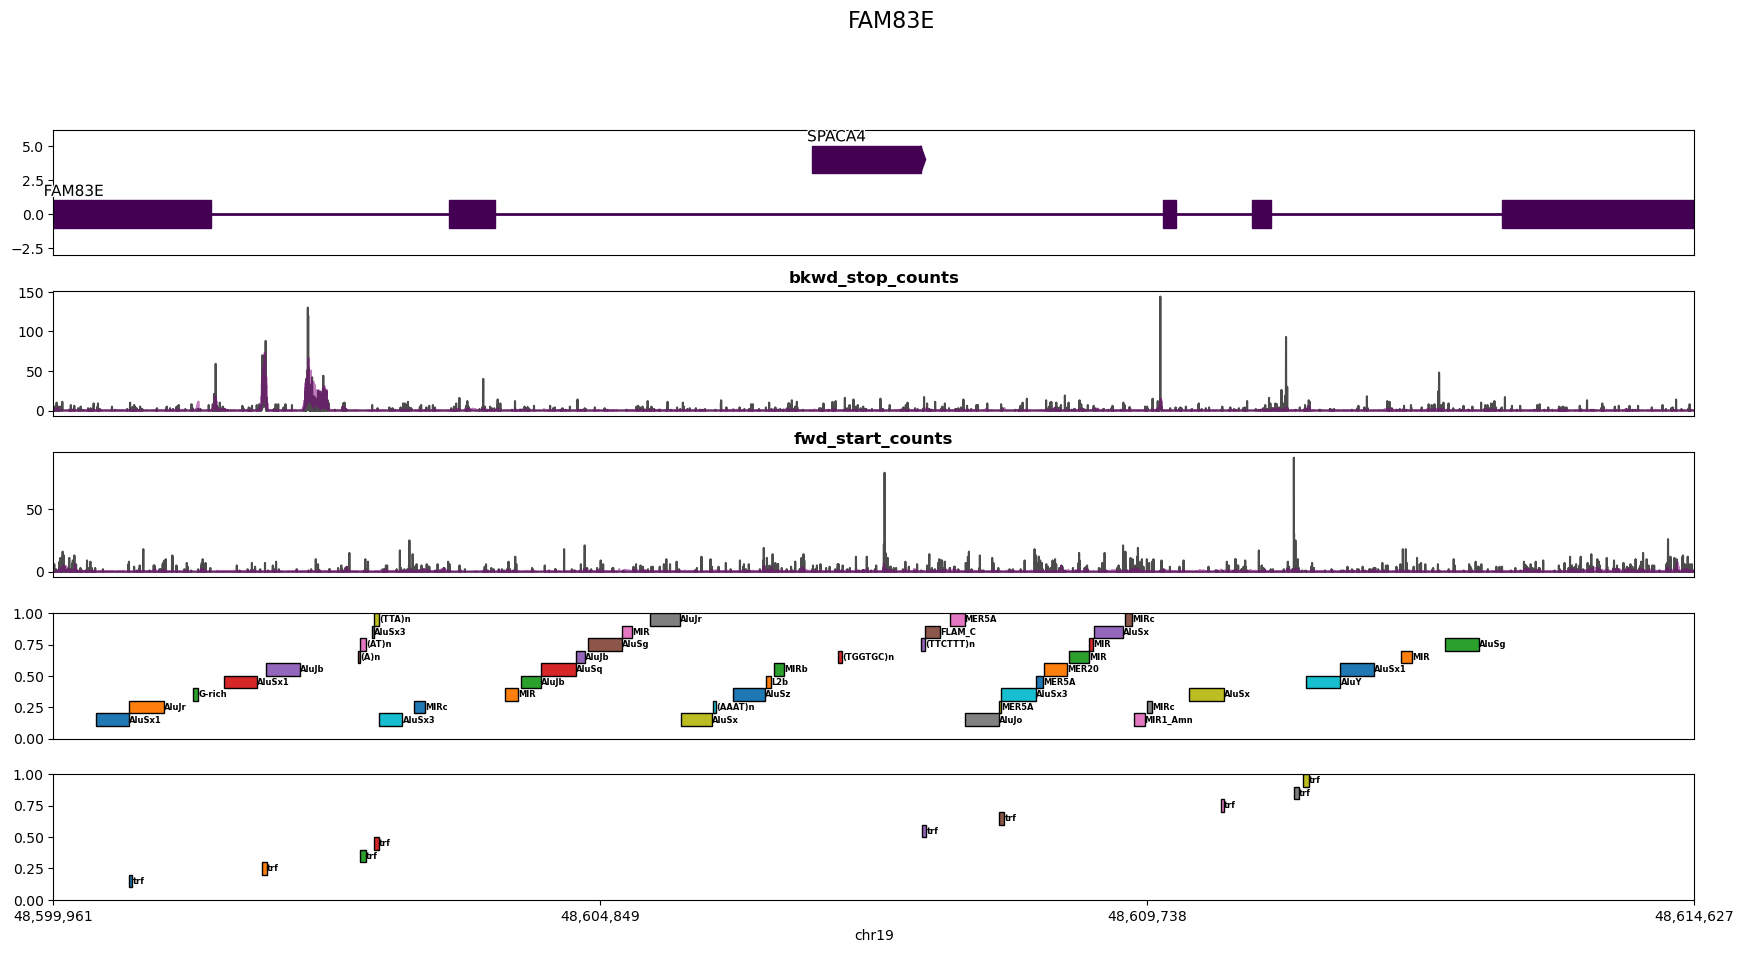

In [637]:
_ = plot_gene(model, 'FAM83E') # TINAG

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 31.35it/s]


fwd_start_counts        14393.000000
bkwd_stop_counts         6102.000000
fwd_start_counts_hat    14673.355884
bkwd_stop_counts_hat     6611.711856
dtype: float64


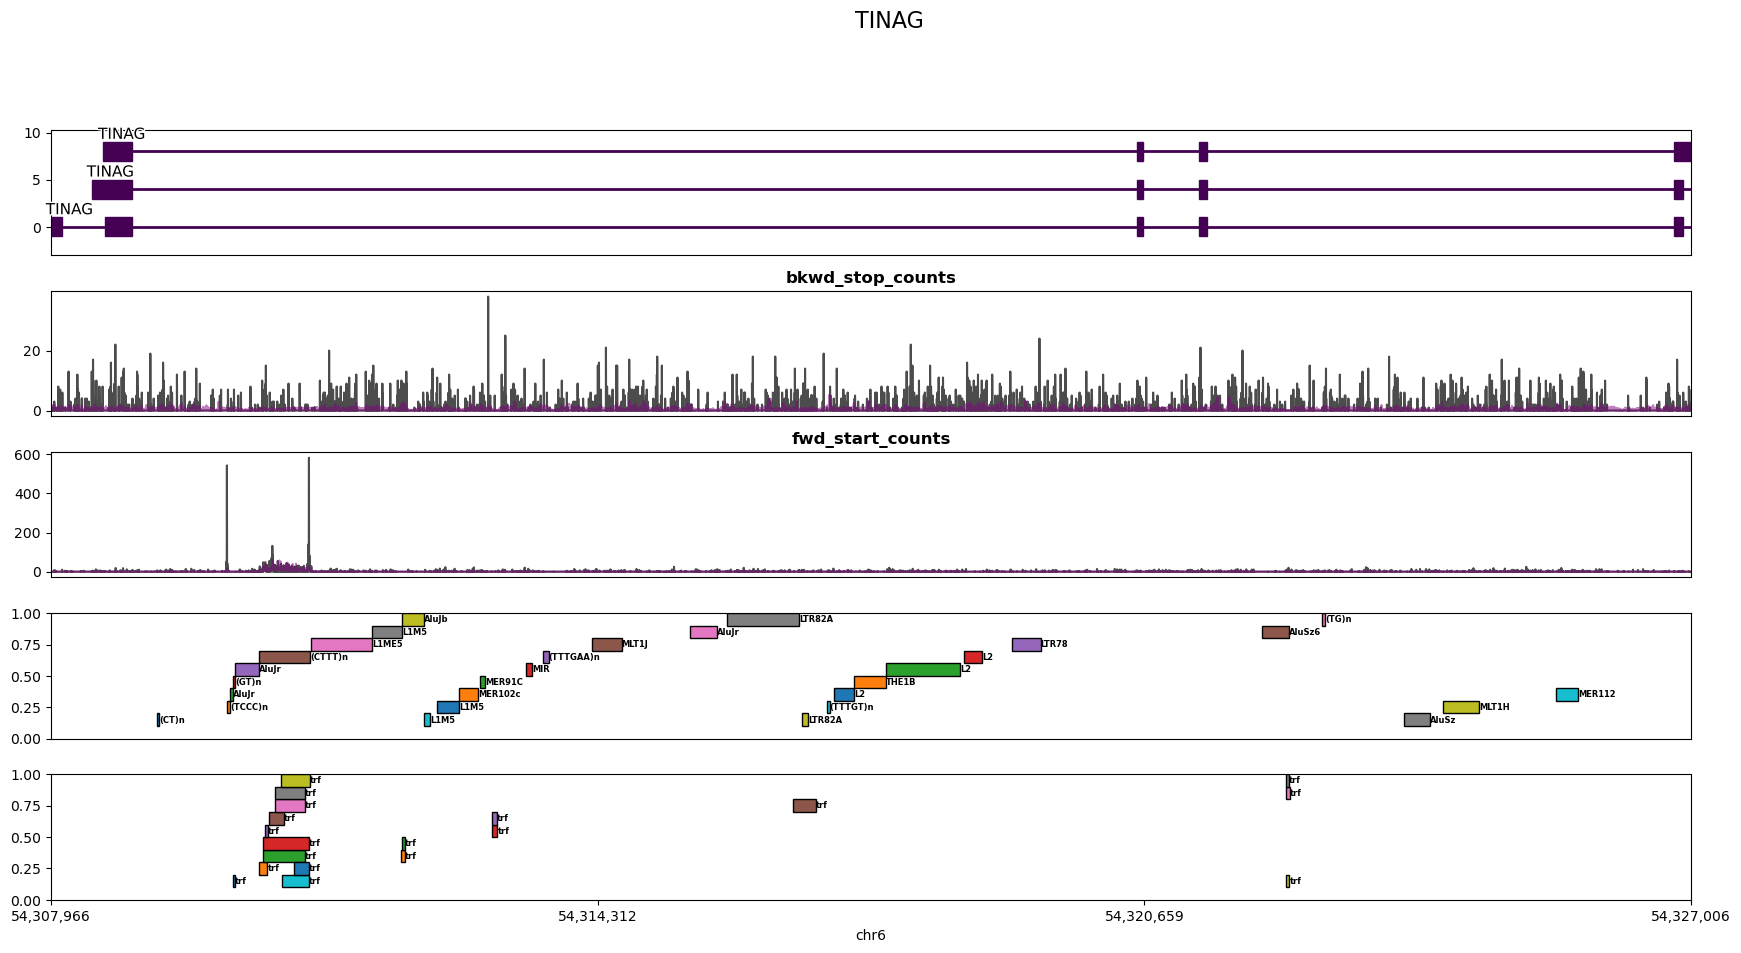

In [636]:
_ = plot_gene(model, 'TINAG') # TINAG

In [418]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(hge_raw, load_ibd_sample_df()).attach_fragment_arrays(num_cores=32)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312354/312354 [04:37<00:00, 1125.76it/s]


In [428]:
from tqdm.notebook import tqdm
tqdm.pandas()
merged_fas = srdf.groupby("gene_id").progress_apply(lambda x: merge_fragment_arrays(x.fragment_array.tolist())).rename('fragment_array')

  0%|          | 0/17353 [00:00<?, ?it/s]

In [572]:
def build_dist(self, pred):
    rv = []
    for i in range(len(self.output_columns)):
        ps = 1-logits_to_probs(torch.Tensor(pred[i]), is_binary=True)
        total_counts = model.loss_fn._transform_counts(torch.Tensor(pred[i+2]))
        dist = nbinom(n=total_counts, p=ps)
        rv.append(dist)
    return rv

def predict_from_rdf(self, rdf):
    rdf = rdf.resize_regions(self.calc_input_region_size(rdf.region_lengths))
    seq = rdf.get_one_hot_encoded_sequence(FASTA_PATH, verbose=True)

    self.cuda()
    self.eval()
    pred = seq.progress_apply(lambda x: self.model(torch.Tensor(x).cuda()).cpu().detach().numpy())
    dists = [build_dist(self, x) for x in tqdm(pred)]

    return pd.DataFrame(dists, columns=[x + "_dist" for x in model.output_columns], index=rdf.index)

In [626]:
pred_dists = predict_from_rdf(model, hge_raw.set_index('gene_id'))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17353/17353 [00:09<00:00, 1864.93it/s]


  0%|          | 0/17353 [00:00<?, ?it/s]

  0%|          | 0/17353 [00:00<?, ?it/s]

In [627]:
pred_columns = [c[:-5] for c in pred_dists.columns]
obs_counts = merged_fas.progress_apply(lambda x: pd.Series(list(FragmentEndpointsDataset.get_targets_from_region_fragment_array(x, pred_columns).cpu().detach().numpy())))
obs_counts = pd.DataFrame(obs_counts).rename(columns=dict(enumerate(pred_columns)))

  0%|          | 0/17353 [00:00<?, ?it/s]

In [702]:
tmp = hge_raw.set_index('gene_id').join(obs_counts.join(pred_dists, how='inner')).reset_index()

In [706]:
def make_tracks(record, sharey=False, smooth=False):
    region = Region(record.contig, record.start, record.stop, strand=record.strand)
    base_columns = [c for c in record.index.tolist() if c.endswith("_counts")]
    tracks = Tracks()
    tracks.append(GeneTrack("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz", region))

    all_counts = [record[c] for c in base_columns]
    dists = [record[c + "_dist"] for c in base_columns]

    if sharey:
        ylim = (0, int(self.max().max()*1.1))
    else:
        ylim = None

    return pd.DataFrame([
        [record.gene_id, record.gene_name, base_column, counts.sum(), dist.mean().sum()] 
        for base_column, counts, dist in zip(base_columns, all_counts, dists)], 
        columns=['gene_id', 'gene_name', 'name', 'obs_counts', 'pred_counts']
    )

    for base_column, counts, dist in zip(base_columns, all_counts, dists):
        track = VectorTrack(counts, region, name=f"Observed - {base_column}", color='black', alpha=0.7, ylim=ylim, smooth=smooth) + \
                VectorTrack(dist.mean(), region, name=f"Predicted - {base_column}", color='purple', alpha=0.5, ylim=ylim, smooth=smooth) + \
                VectorTrack(dist.ppf(0.95), region, name=f"Predicted - {base_column}", color='orange', alpha=0.5, ylim=ylim, smooth=smooth)

        track.name = base_column
        tracks.append(track)

    tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", region))
    tracks.append(BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", region))

    return tracks


In [707]:
tmp

,gene_id,gene_name,contig,strand,start,stop,expression,fwd_start_counts,bkwd_stop_counts,fwd_start_counts_dist,bkwd_stop_counts_dist
0,ENSG00000121410,A1BG,chr19,-,58345183,58353492,62.542394,"[3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
1,ENSG00000148584,A1CF,chr10,-,50799409,50859985,0.000000,"[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
2,ENSG00000175899,A2M,chr12,-,9067708,9115919,0.077835,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
3,ENSG00000166535,A2ML1,chr12,+,8822621,8875012,0.197852,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 14.0, 0.0,...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
4,ENSG00000128274,A4GALT,chr22,-,42692121,42695631,2.158199,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...,...,...,...,...,...,...,...,...,...
17348,ENSG00000070476,ZXDC,chr3,-,126437601,126475891,19.699126,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17349,ENSG00000203995,ZYG11A,chr1,+,52842511,52893790,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17350,ENSG00000162378,ZYG11B,chr1,+,52726453,52805524,28.688477,"[3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17351,ENSG00000159840,ZYX,chr7,+,143381345,143391109,118.715634,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...


In [708]:
make_tracks(tmp.iloc[52])

,gene_id,gene_name,name,obs_counts,pred_counts
0,ENSG00000140798,ABCC12,fwd_start_counts,2784.0,3864.916522
1,ENSG00000140798,ABCC12,bkwd_stop_counts,2479.0,3109.082997


In [711]:
tmp

,gene_id,gene_name,contig,strand,start,stop,expression,fwd_start_counts,bkwd_stop_counts,fwd_start_counts_dist,bkwd_stop_counts_dist
0,ENSG00000121410,A1BG,chr19,-,58345183,58353492,62.542394,"[3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
1,ENSG00000148584,A1CF,chr10,-,50799409,50859985,0.000000,"[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
2,ENSG00000175899,A2M,chr12,-,9067708,9115919,0.077835,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
3,ENSG00000166535,A2ML1,chr12,+,8822621,8875012,0.197852,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 14.0, 0.0,...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
4,ENSG00000128274,A4GALT,chr22,-,42692121,42695631,2.158199,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...,...,...,...,...,...,...,...,...,...
17348,ENSG00000070476,ZXDC,chr3,-,126437601,126475891,19.699126,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17349,ENSG00000203995,ZYG11A,chr1,+,52842511,52893790,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17350,ENSG00000162378,ZYG11B,chr1,+,52726453,52805524,28.688477,"[3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17351,ENSG00000159840,ZYX,chr7,+,143381345,143391109,118.715634,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...


In [807]:
def calc_stats(record):
    base_columns = [c for c in record.index.tolist() if c.endswith("_counts")]

    all_counts = [record[c] for c in base_columns]
    dists = [record[c + "_dist"] for c in base_columns]

    rv = {}
    for c, counts, dist in zip(base_columns, all_counts, dists):
        rv[c + "_count"] = counts.sum()
        rv[c + "_pred_count"] = dist.mean().sum()
        rv[c + "_l1_loss"] = np.abs(dist.mean() - counts).mean()
        rv[c + "_frac_over_95_conf"] = (counts > dist.ppf(0.95)).mean()
        # rv[c + "_frac_over_99_conf"] = (counts > dist.ppf(0.99)).mean()
    return pd.Series(rv)

In [808]:
# stats = pd.DataFrame(tmp).progress_apply(lambda x: pd.Series(dict(gene_name=x.gene_name, counts=x.fwd_start_counts.sum(), pred_counts=x.fwd_start_counts_dist.mean().sum())), axis=1)
# rev_counts = pd.DataFrame(tmp).progress_apply(lambda x: pd.Series(dict(gene_name=x.gene_name, counts=x.bkwd_end_counts.sum(), pred_counts=x.fwd_start_counts_dist.mean().sum())), axis=1)

In [825]:
test = tmp.split(1000)
test[0]

,gene_id,gene_name,contig,strand,start,stop,expression,fwd_start_counts,bkwd_stop_counts,fwd_start_counts_dist,bkwd_stop_counts_dist
0,ENSG00000121410,A1BG,chr19,-,58345183,58353492,62.542394,"[3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
1,ENSG00000148584,A1CF,chr10,-,50799409,50859985,0.000000,"[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
2,ENSG00000175899,A2M,chr12,-,9067708,9115919,0.077835,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
3,ENSG00000166535,A2ML1,chr12,+,8822621,8875012,0.197852,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 14.0, 0.0,...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
4,ENSG00000128274,A4GALT,chr22,-,42692121,42695631,2.158199,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
5,ENSG00000118017,A4GNT,chr3,-,138123713,138131282,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 4.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
6,ENSG00000094914,AAAS,chr12,-,53307459,53315782,29.132218,"[0.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
7,ENSG00000081760,AACS,chr12,+,125065435,125143316,10.323724,"[0.0, 0.0, 7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
8,ENSG00000114771,AADAC,chr3,+,151814073,151824860,0.023510,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[11.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 14.0...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
9,ENSG00000197953,AADACL2,chr3,+,151733927,151761339,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...


In [820]:
%%time
import dask.dataframe as dd
ddf = dd.from_pandas(pd.DataFrame(tmp).head(100), npartitions=10)
ddf_update = ddf.apply(calc_stats, axis=1).compute()
# stats = .parallel_apply(calc_stats, axis=1)

AttributeError: module 'dask.dataframe' has no attribute 'core'

In [819]:
stats

[autoreload of dask.optimization failed: Traceback (most recent call last):
  File "/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 319, in update_instances
    refs = gc.get_referrers(old)
Keyboard

,fwd_start_counts_count,fwd_start_counts_pred_count,fwd_start_counts_l1_loss,fwd_start_counts_frac_over_95_conf,bkwd_stop_counts_count,bkwd_stop_counts_pred_count,bkwd_stop_counts_l1_loss,bkwd_stop_counts_frac_over_95_conf
0,2342.0,3113.123688,0.562005,0.030208,3569.0,3646.242774,0.604056,0.029005
1,18271.0,27554.931634,0.653833,0.030474,19764.0,24864.315293,0.635547,0.035261
2,14076.0,22288.364619,0.649678,0.027940,14867.0,19163.252464,0.607693,0.032088
3,14102.0,21537.747912,0.587984,0.026932,17651.0,22486.222639,0.629499,0.031551
4,759.0,1356.430990,0.516273,0.022792,640.0,1262.855705,0.489237,0.023077
...,...,...,...,...,...,...,...,...
95,25043.0,40865.847764,0.561961,0.025431,32277.0,40554.987406,0.622130,0.032343
96,4784.0,6220.893337,0.700327,0.026218,3100.0,4681.514748,0.527932,0.027089
97,81699.0,119009.148917,0.700023,0.030790,76776.0,98121.164296,0.616385,0.033963
98,45360.0,71249.693542,0.578112,0.026995,52157.0,70258.432660,0.594102,0.030763


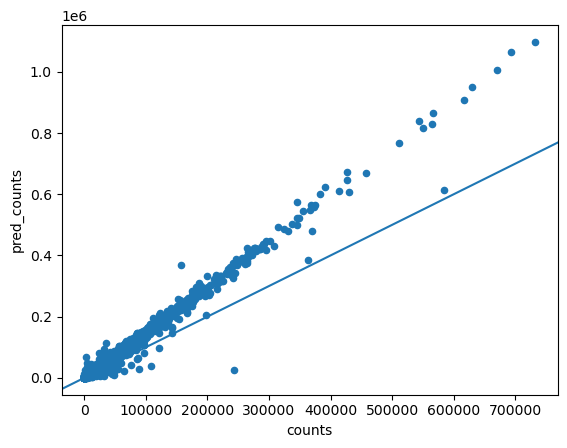

In [739]:
ax = fwd_counts.set_index("gene_name").plot.scatter(x='counts', y='pred_counts')
ax.axline((0, 0), slope=1)

In [577]:
pred_dists # .join(merged_fas.rename('fragment_array'), how='inner')

,fwd_start_counts_dist,bkwd_stop_counts_dist
gene_id,,
ENSG00000121410,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
ENSG00000148584,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
ENSG00000175899,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
ENSG00000166535,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
ENSG00000128274,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...
ENSG00000138443,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
ENSG00000108798,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
ENSG00000154175,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...


  0%|          | 0/17353 [00:00<?, ?it/s]

  0%|          | 0/17353 [00:00<?, ?it/s]

,fwd_start_counts_dist,bkwd_stop_counts_dist
0,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
1,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
2,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
3,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
4,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...
17348,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17349,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17350,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
17351,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...


In [459]:
pd.DataFrame(merged_fas.rename('fragment_array')).join(seq) # .join(merged_fas)

,fragment_array,one_hot_encoded_sequence
gene_id,,
ENSG00000000003,"RegionFragmentArray(n_frags=13335, region=chrX...","[[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,..."
ENSG00000000005,"RegionFragmentArray(n_frags=27788, region=chrX...","[[0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,..."
ENSG00000000419,"RegionFragmentArray(n_frags=16555, region=chr2...","[[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,..."
ENSG00000000457,"RegionFragmentArray(n_frags=67402, region=chr1...","[[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,..."
ENSG00000000460,"RegionFragmentArray(n_frags=5715, region=chr1:...","[[1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,..."
...,...,...
ENSG00000288722,"RegionFragmentArray(n_frags=1170, region=chrX:...","[[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,..."
ENSG00000288784,"RegionFragmentArray(n_frags=1944, region=chr7:...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
ENSG00000288867,"RegionFragmentArray(n_frags=677, region=chr1:+...","[[1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,..."


In [389]:
rfa = merge_fragment_arrays(SampleAndRegionDataFrame.init_from_rdf_and_sdf(hge_raw.query("gene_name == 'TINAG'"), load_ibd_sample_df()).attach_fragment_arrays().fragment_array)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 187.49it/s]


In [406]:
%%time
res = predict_for_genes(model, gene_names = srdf_raw.gene_name.value_counts().sample(10).index.tolist()) # ['TBX10', 'FAM83E', 'BEST2', 'MUC17', 'B3GNT6', 'CDSN'])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 177.56it/s]


CPU times: user 6min 4s, sys: 3min 33s, total: 9min 37s
Wall time: 53.7 s


In [408]:
res

,KLHL14,PSME4,SHANK3,TRIB1,FCGBP,ACTR1B,OR10G4,BRWD3,FBXO25,SLC17A6
fwd_start_counts,31029.000000,31575.000000,17672.000000,2204.000000,25965.000000,2851.000000,1987.000000,42030.000000,14442.000000,11807.000000
bkwd_stop_counts,33297.000000,24916.000000,21039.000000,2021.000000,31176.000000,2827.000000,1547.000000,36193.000000,17054.000000,12812.000000
fwd_start_counts_hat,33770.799109,37425.658294,17486.260867,2099.304227,24748.941879,3212.347109,1970.689314,52474.864867,17363.910542,13447.770890
bkwd_stop_counts_hat,32266.392022,26832.182562,23565.950885,2101.249640,24613.690227,1914.850304,1744.118708,43743.981349,19439.631828,12288.241696


<Axes: >

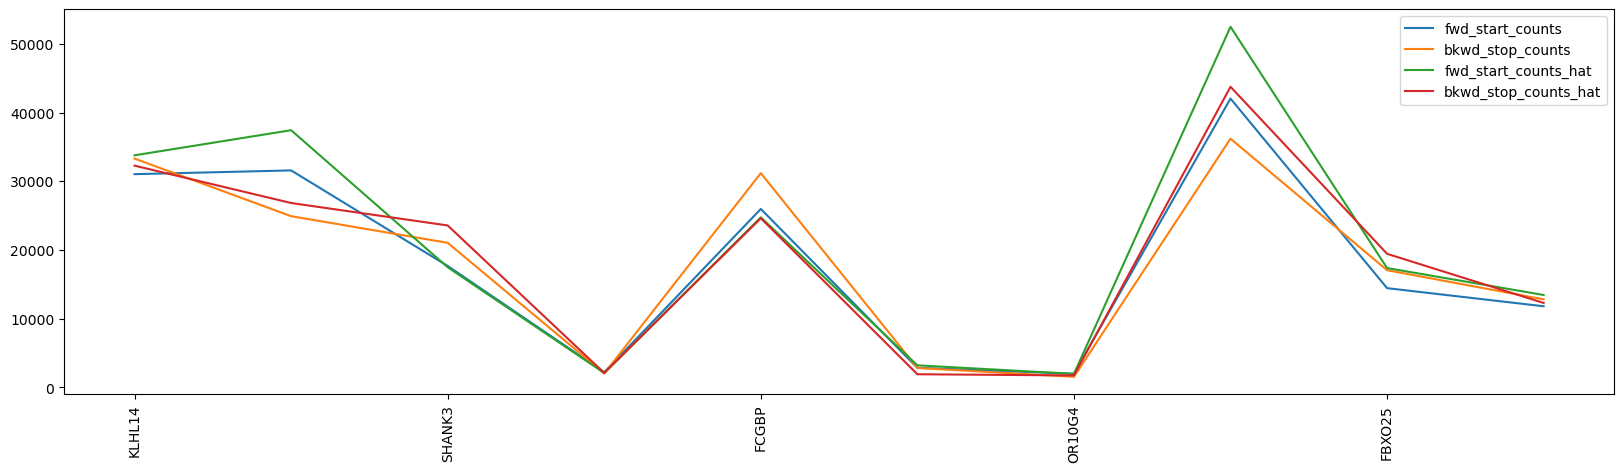

In [407]:
res.T.plot(rot=90, figsize=(20, 5))

<Axes: >

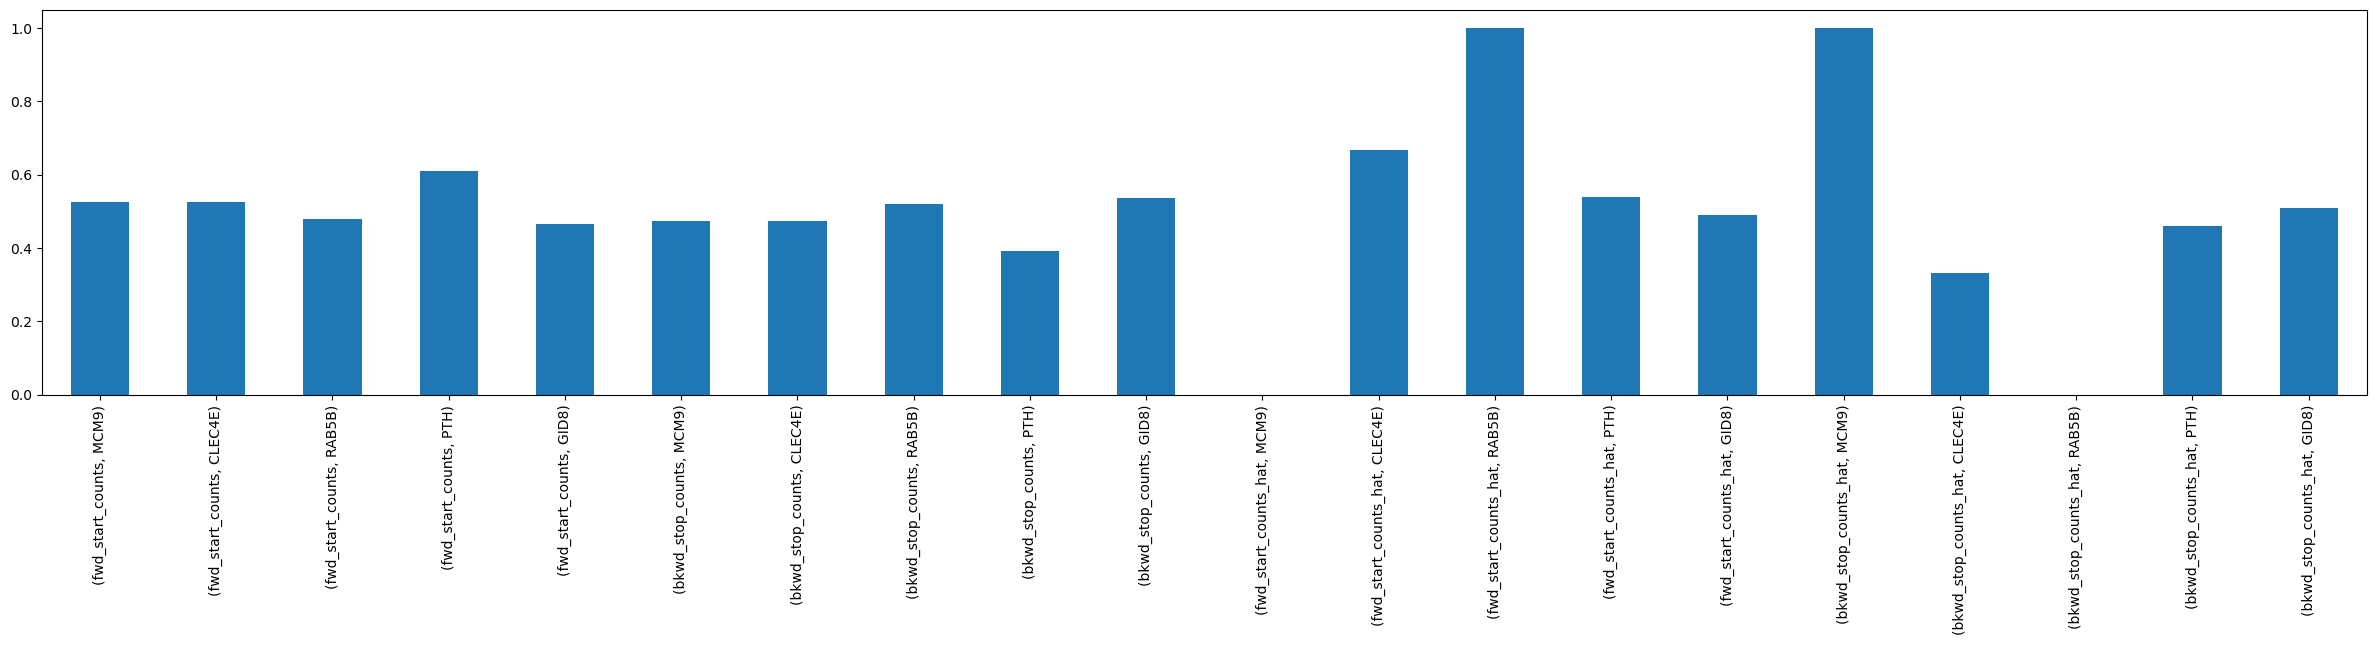

In [377]:
res.stack().plot.bar(figsize=(30, 5))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 195.19it/s]


fwd_start_counts        2976.0
bkwd_stop_counts        4398.0
fwd_start_counts_hat    2976.0
bkwd_stop_counts_hat    4398.0
dtype: float64


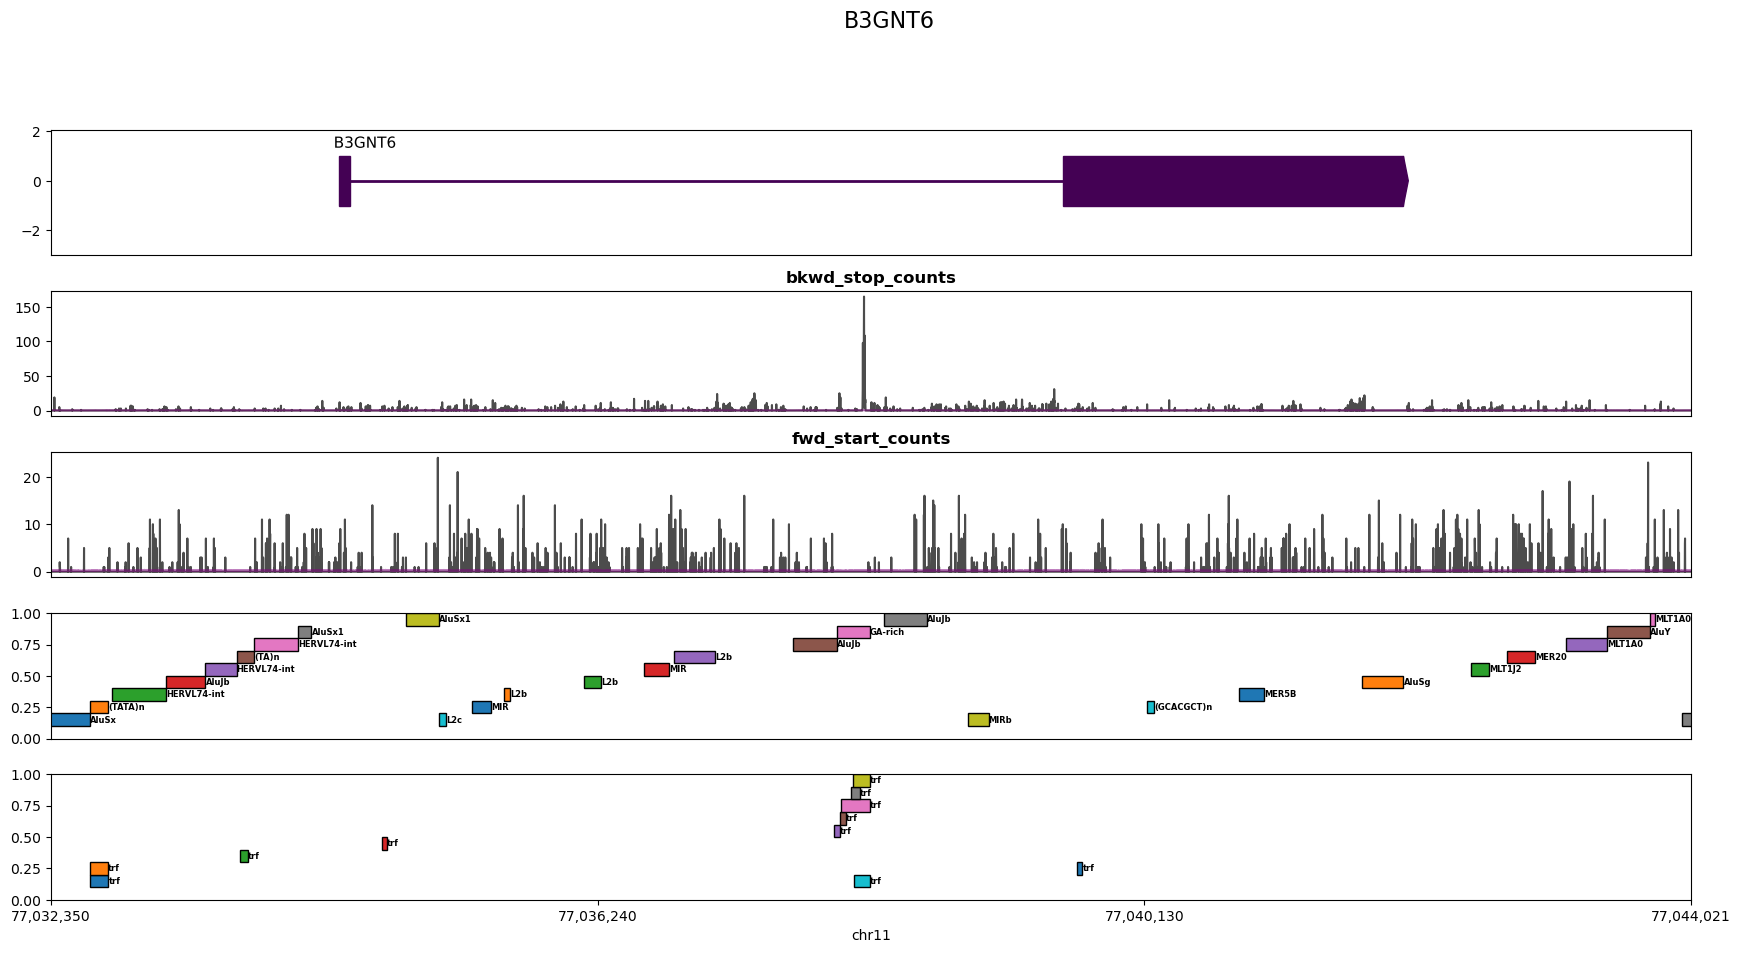

In [487]:
plot_gene('B3GNT6')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 204.16it/s]


fwd_start_counts     4648.0
bkwd_start_counts    8369.0
fwd_stop_counts      4665.0
bkwd_stop_counts     8362.0
dtype: float64


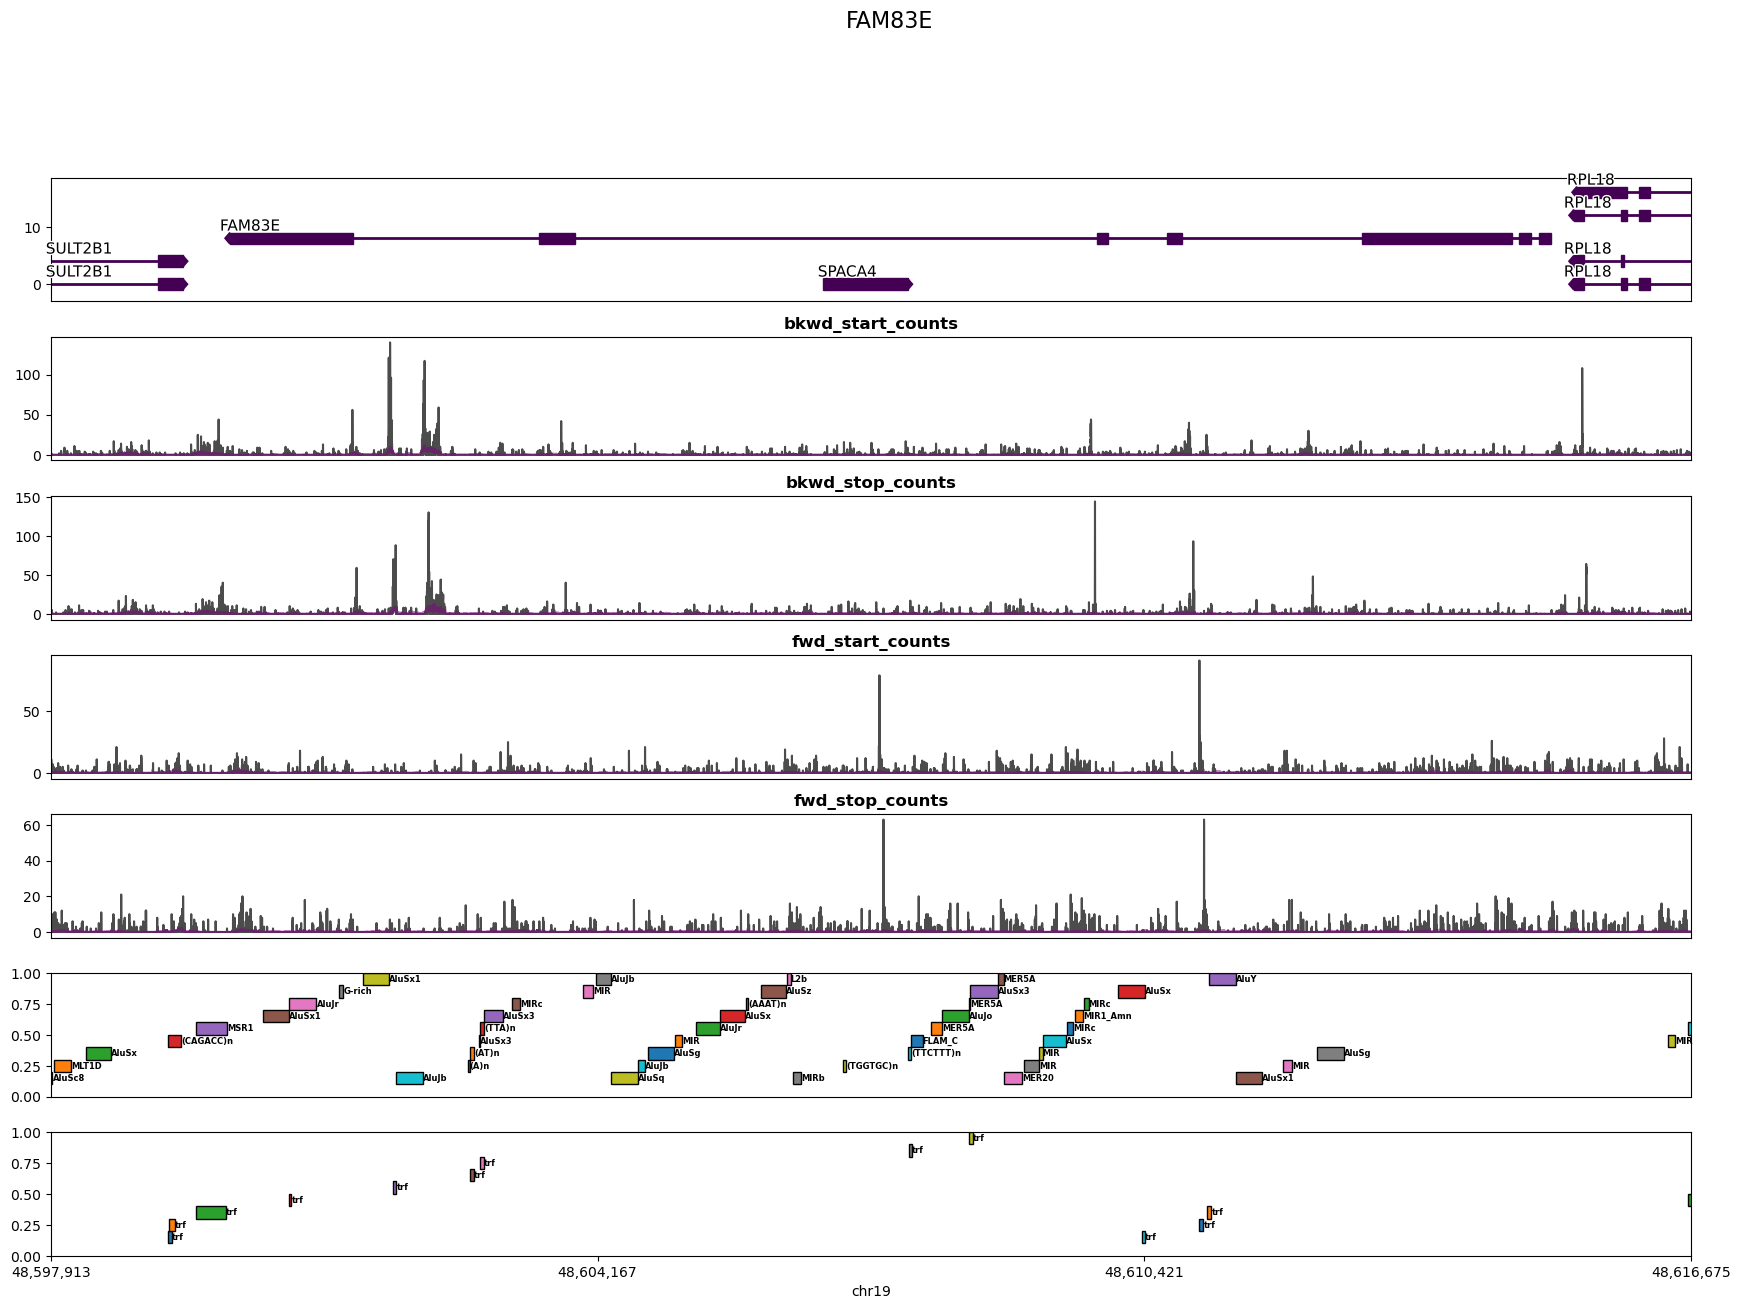

In [316]:
plot_gene('FAM83E')

In [304]:
df = predict_from_region_fragment_array(background_model, rfa)

WARNING	2024-03-25 07:29:27,353	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "



In [305]:
df.sum()

fwd_start_counts          2797.000000
bkwd_start_counts         1689.000000
fwd_stop_counts           2797.000000
bkwd_stop_counts          1680.000000
fwd_start_counts_hat      9783.104447
bkwd_start_counts_hat    13344.378511
fwd_stop_counts_hat      22844.608189
bkwd_stop_counts_hat      7178.978394
dtype: float64

(<Figure size 2500x1400 with 7 Axes>,
 [<Axes: >,
  <Axes: title={'center': 'fwd_start_counts'}>,
  <Axes: title={'center': 'bkwd_start_counts'}>,
  <Axes: title={'center': 'fwd_stop_counts'}>,
  <Axes: title={'center': 'bkwd_stop_counts'}>,
  <Axes: >,
  <Axes: xlabel='chr7'>])

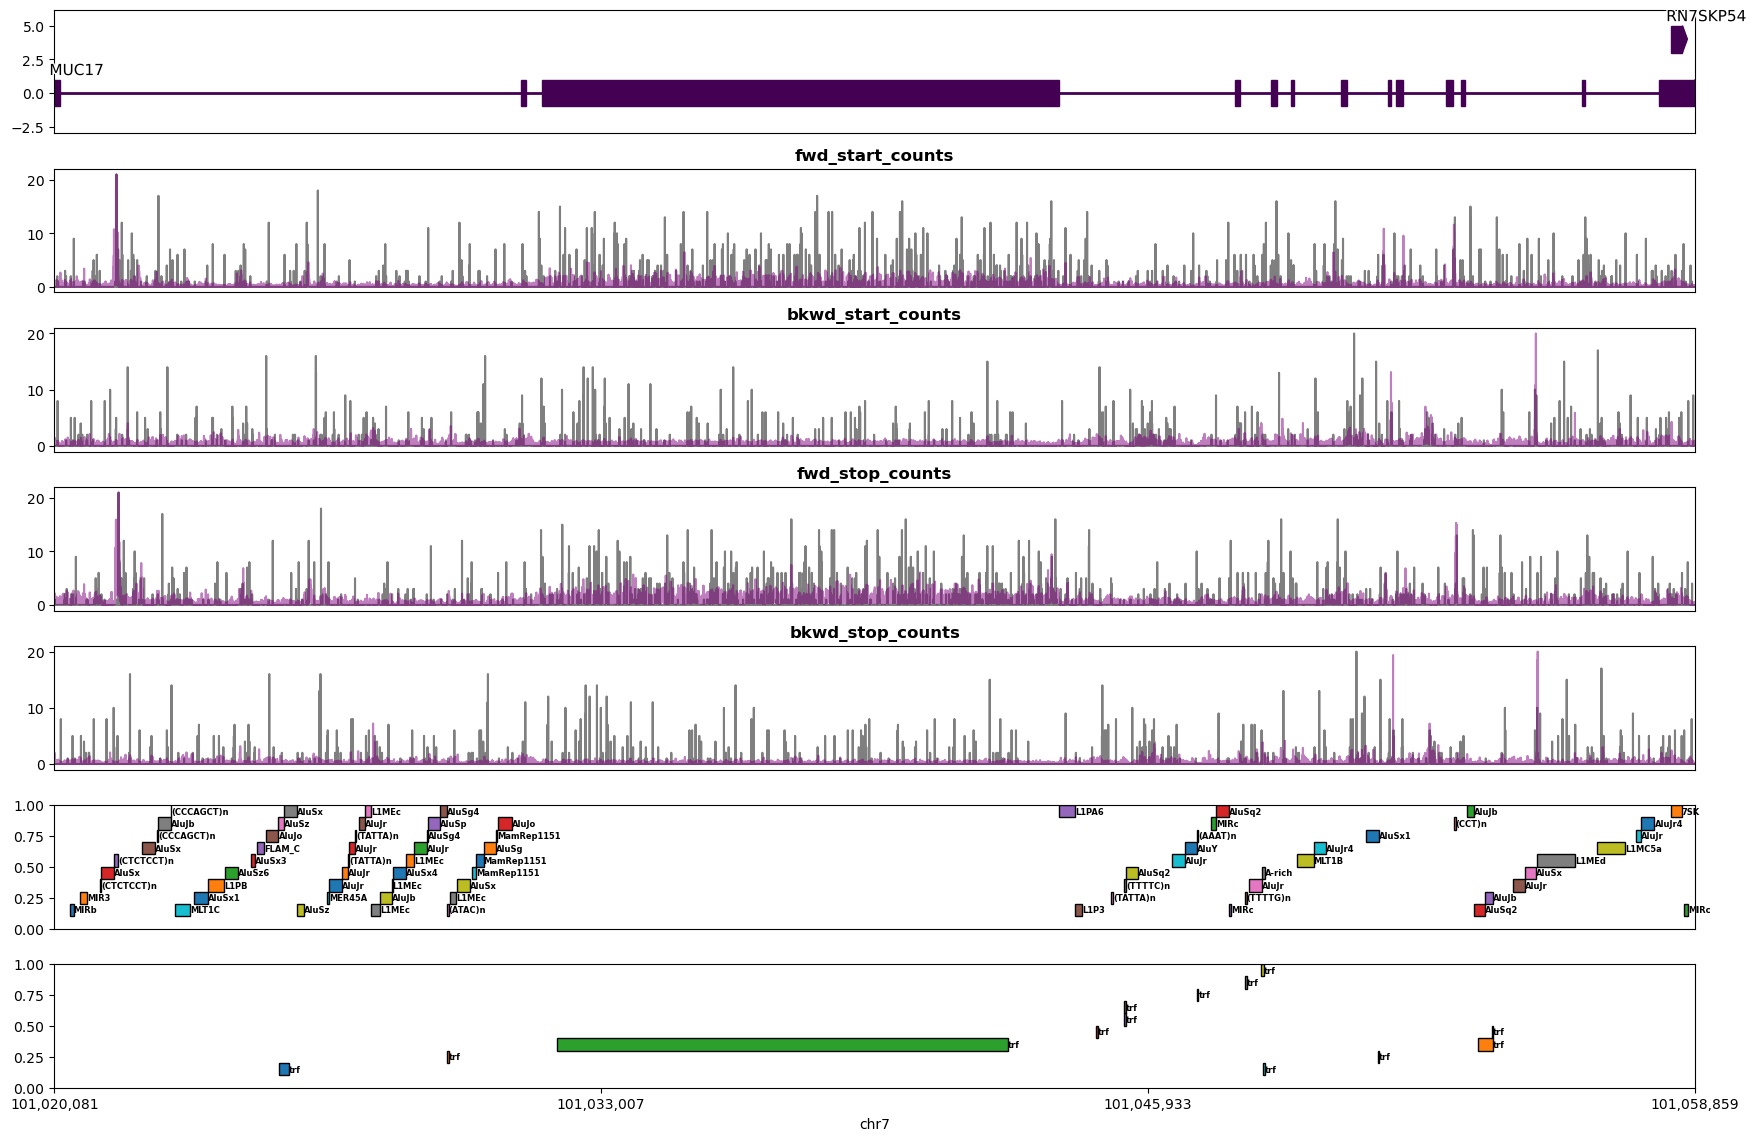

In [306]:
df.make_tracks().plot()

# Old Method

In [168]:
import itertools
from typing import Optional # , Dict, Type, Union, Tuple, List

from typing import Dict, Optional, List, Set, Type, Union

import numpy
import pandas
import torch
import torch.optim as optim
from torch.nn.modules.loss import _Loss

import matplotlib.pyplot as plt

from fragmentomics_tools.dataframe import DataFrameBase
from fragmentomics_tools.region import Region

# from ravel.learn.functional_genomics.losses import MultinomialNLLLoss

from scipy.stats import multinomial
from scipy.special import softmax

def calculate_start_and_stop_from_jitter(
    input_length, output_length, jitter_value, strand: Optional[str] = None
):
    """
    Calculates the new start and stop of a region given some +/- jitter value and output length
    Importantly, this is only defined on input / output lengths of the same parity:
        allowed: (even, even), (odd, odd)
        disallowed: (even, odd), (odd, even)
    :param input_length: length of input region
    :param output_length: desired output length of region
    :param jitter_value: a +/- value from the center of the input region by which to shift window
    :param strand: Optional strand, if not supplied this will default to assuming the user wants + strand.
    :return: coordinates for, e.g., slicing
    """
    if input_length < output_length + numpy.abs(jitter_value):
        raise ValueError(
            f"input array is not wide enough to allow for an output of"
            f" length {output_length} with jitter_value of {jitter_value}."
        )

    resize_start = Region.get_resize_start(
        start=0, current_size=input_length, new_size=output_length, strand=strand
    )
    jitter_start = resize_start + jitter_value
    jitter_stop = jitter_start + output_length
    return jitter_start, jitter_stop


def jitter_matrix(input_arr, jitter_value, output_length, strand: Optional[str] = None):
    input_length = input_arr.shape[-1]

    if round(jitter_value) != jitter_value:
        raise ValueError(f"jitter_range must be a whole number, received {jitter_value}.")

    if input_length < output_length + numpy.abs(jitter_value):
        raise ValueError(
            f"input array is not wide enough to allow for an output of"
            f" length {output_length} with jitter_value of {jitter_value}."
        )

    new_start, new_stop = calculate_start_and_stop_from_jitter(
        input_length=input_length, output_length=output_length, jitter_value=jitter_value, strand=strand
    )
    assert new_stop - new_start == output_length, (output_length, new_stop, new_start)
    assert new_start >= 0, new_start
    assert new_stop <= input_length, (new_stop, input_length)

    if isinstance(input_arr, numpy.ndarray) or isinstance(input_arr, torch.Tensor):
        jittered_output = input_arr[..., new_start:new_stop]
    elif scipy.sparse.issparse(input_arr):
        indices = numpy.where((input_arr.col < new_stop) & (input_arr.col >= new_start))[0]

        jittered_output = coo_matrix(
            (
                numpy.ones(len(indices)),
                (input_arr.row[indices], input_arr.col[indices] - new_start),
            ),
            shape=[input_arr.shape[0], output_length],
            dtype=input_arr.dtype,
        )
    else:
        raise TypeError(f"input_arr type {type(input_arr)} is invalid.")

    return jittered_output


class BackgroundModelPredictionsDataFrame(DataFrameBase):
    _metadata = ["paired_columns"]

    @classmethod
    def init_from_counts(
        cls,
        fwd_start_counts,
        fwd_start_counts_hat,
        bkwd_start_counts,
        bkwd_start_counts_hat,
        fwd_stop_counts,
        fwd_stop_counts_hat,
        bkwd_stop_counts,
        bkwd_stop_counts_hat,
    ):
        data = pandas.DataFrame(
            dict(
                fwd_start_counts=fwd_start_counts,
                fwd_start_counts_hat=fwd_start_counts_hat,
                bkwd_start_counts=bkwd_start_counts,
                bkwd_start_counts_hat=bkwd_start_counts_hat,
                fwd_stop_counts=fwd_stop_counts,
                fwd_stop_counts_hat=fwd_stop_counts_hat,
                bkwd_stop_counts=bkwd_stop_counts,
                bkwd_stop_counts_hat=bkwd_stop_counts_hat,
            )
        )
        return cls(data)

    def __init__(self, data, *args, **kwargs):
        super().__init__(data, *args, **kwargs)

        self.paired_columns = [
            ("fwd_start_counts", "fwd_start_counts_hat"),
            ("bkwd_start_counts", "bkwd_start_counts_hat"),
            ("fwd_stop_counts", "fwd_stop_counts_hat"),
            ("bkwd_stop_counts", "bkwd_stop_counts_hat"),
        ]

        if isinstance(data, pandas.core.internals.BlockManager):
            return

    def calc_lhd(self):
        lhd = 0
        for obs, pred in self.paired_columns:
            p = self[pred] / self[pred].sum()
            lhd += multinomial.logpmf(x=self[obs].to_numpy(), p=p, n=self[obs].sum())
        return lhd/len(self)

    def plot_summary(self, figsize=(20, 10)):
        fig, axarray = plt.subplots(4, 3, figsize=figsize, sharey="col")
        for i, (obs_cname, pred_cname) in enumerate(self.paired_columns):
            (self[obs_cname] / self[pred_cname]).plot(ax=axarray[i, 0])
            axarray[i, 0].axhline(1, c="black")
            _ = DataFrameBase(self[[obs_cname, pred_cname]]).plot(ax=axarray[i, 1])
            super().plot.scatter(x=obs_cname, y=pred_cname, ax=axarray[i, 2])
            axarray[i, 2].axline([0, 0], [1, 1], c="red")


class BackgroundModel:
    def __init__(self, path=None, residual_layers=1):
        if path is not None:
            state_dict = torch.load(path)
            self.kernel_size = state_dict.pop("kernel_size")
            self.num_filters = state_dict.pop("num_filters")
        else:
            self.kernel_size = 64
            self.num_filters = 64

        self.residual_layers = residual_layers
        self.verbose = True
        self.num_workers = 64

        self.model = self.get_model()
        if path is not None:
            self.model.load_state_dict(state_dict)
        self.model.cuda()

    def get_small_model(self):
        return torch.nn.Sequential(
            *[
                torch.nn.Conv1d(
                    in_channels=4,
                    out_channels=self.num_filters,
                    kernel_size=self.kernel_size,
                    padding="valid",
                ),
                torch.nn.Conv1d(
                    in_channels=self.num_filters,
                    out_channels=4,
                    kernel_size=self.kernel_size,
                    padding="valid",
                ),
            ]
        ) 
    
    def get_model(self):
        dropout=0.15
        input_channels = 4
        residual_layers = self.residual_layers
        n_kernels = 512
        
        initial_layer = nn.Sequential(
            nn.Conv1d(
                in_channels=input_channels,
                out_channels=n_kernels,  # one per strand so will be doubled
                kernel_size=self.kernel_size,
                padding=0,  # initial_kernel_size // 2,
            ),
            nn.LeakyReLU(),
            SpatialDropout(p=dropout),
        )
        
        res_net_layers = []
        res_net_layers.extend(
            [
                ResNetDilatedBlock(
                    dilation_rate=2**i,
                    input_channels=n_kernels,
                    activation=nn.LeakyReLU,
                    profile_kernel_size=self.kernel_size,
                    activation_post_sum=True,
                    skip_batchnorm=False,
                    preact_residual_normalization=False,
                    padding=0,
                )
                for i in range(1, residual_layers+1)
            ]
        )
        
        final_layer = nn.Conv1d(
            in_channels=n_kernels,
            out_channels=4,
            kernel_size=(self.kernel_size,),
            padding=0,  # 0 padding here to make up for previous convtranspose expansion
        )
        
        layers = [initial_layer] + res_net_layers + [final_layer]

        return nn.Sequential(*layers)

    def save(self, path):
        state_dict = self.model.state_dict()
        state_dict["kernel_size"] = self.kernel_size
        state_dict["num_filters"] = self.num_filters
        torch.save(state_dict, path)

    def calc_input_region_size(self, output_region_size):
        return output_region_size + 2*(model.kernel_size-1) + sum([(model.kernel_size-1)*(2**i) for i in range(1, self.residual_layers+1)])

    def _build_resized_one_hot_encoded_seq(self, rdf):
        sizes = list(rdf.region_lengths.drop_duplicates())
        assert len(sizes) == 1
        output_region_size = sizes[0]
        input_region_size = self.calc_input_region_size(output_region_size)
        print("Calculated size:", input_region_size)
        one_hot_encoded_sequences = rdf.resize_regions(input_region_size).get_one_hot_encoded_sequence(FASTA_PATH)
        return one_hot_encoded_sequences

    def _build_resized_fragment_arrays(self, srdf):
        return srdf.load_fragment_arrays(num_cores=self.num_workers)

    def predict_from_seq(self, seq):
        one_hot_seq = one_hot_encode_sequences([seq.encode(),])[0, :, :].T
        one_hot_seq = torch.Tensor(one_hot_seq)[None, :].cuda()
        return softmax(self.model(one_hot_seq).cpu().detach().numpy()[0].squeeze().astype("float64"), axis=1)

    def predict(self, rdf, combine_fragment_strands=False):
        model_device = next(self.model.parameters()).device
        # expand the sequences so that we can chop off the filter
        res = []
        with torch.no_grad():
            for idx, seq in self._build_resized_one_hot_encoded_seq(rdf).items():
                seq = torch.Tensor(seq[None, :]).to(model_device)
                rv = softmax(self.model(seq).cpu().numpy()[0].squeeze().astype("float64"), axis=1)
                rv = rv[:, 2 * self.kernel_size : -2 * self.kernel_size]
                res.append(
                    dict(
                        fwd_starts_0_density=rv[0],
                        bkwd_starts_0_density=rv[1],
                        fwd_stops_0_density=rv[2],
                        bkwd_stops_0_density=rv[3],
                    )
                )

        rv = pandas.DataFrame(res, index=rdf.index)
        if combine_fragment_strands:
            rv = pandas.DataFrame(
                dict(
                    starts_0_density=rv.fwd_starts_0_density / 2 + rv.bkwd_starts_0_density / 2,
                    stops_0_density=rv.fwd_stops_0_density / 2 + rv.bkwd_stops_0_density / 2,
                ),
                index=rdf.index,
            )
        return rv

    def iter_train_data(self, one_hot_encoded_sequence, fragment_arrays):
        for i, (one_hot_encoded_sequence, fragment_array) in enumerate(
            zip(one_hot_encoded_sequence, fragment_arrays)
        ):
            # get the inputs; data is a list of [inputs, labels]
            inputs = torch.Tensor(one_hot_encoded_sequence)[None, :].cuda()
            fwd_fa = fragment_array.subset_by_fragment_strand("+")
            bkwd_fa = fragment_array.subset_by_fragment_strand("-")
            targets = torch.cat(
                [
                    torch.Tensor(fwd_fa.first_covered_base_counts.astype(float))[None, :].cuda(),
                    torch.Tensor(bkwd_fa.first_covered_base_counts.astype(float))[None, :].cuda(),
                    torch.Tensor(fwd_fa.last_covered_base_counts.astype(float))[None, :].cuda(),
                    torch.Tensor(bkwd_fa.last_covered_base_counts.astype(float))[None, :].cuda(),
                ],
                dim=0,
            )
            yield inputs, targets

    def _predict_aggregate(self, resized_seq, resized_fas):
        # original_size = resized_seq.tolist()[0].shape[1] - 4 * self.kernel_size
        iterator = self.iter_train_data(resized_seq, resized_fas)
        x, y_agg = next(iterator)
        y_agg = y_agg.cpu()

        with torch.no_grad():
            y_hat_agg = y_agg.cpu().sum(axis=1, keepdim=True) * softmax(
                self.model(x).cpu().numpy()[0].squeeze().astype("float64"), axis=1
            )

        for x, y in iterator:
            with torch.no_grad():
                y_hat = y.cpu().sum(axis=1, keepdim=True) * softmax(
                    self.model(x).cpu().numpy()[0].squeeze().astype("float64"), axis=1
                )
            y_agg += y.cpu()
            y_hat_agg += y_hat

        #y_hat_agg = jitter_matrix(y_hat_agg, 0, original_size)
        #y_agg = jitter_matrix(y_agg, 0, original_size)
        y_hat_agg -= y_hat_agg.mean(axis=1, keepdim=True) - y_agg.mean(axis=1, keepdim=True)
        return BackgroundModelPredictionsDataFrame.init_from_counts(
            *list(itertools.chain(*zip(y_agg, y_hat_agg)))
        )

    def predict_aggregate(self, srdf):
        seq = self._build_resized_one_hot_encoded_seq(srdf)
        fas = self._build_resized_fragment_arrays(srdf)
        return self._predict_aggregate(seq, fas)

    def train(self, train_srdf, test_srdf):
        self.model.cuda()
        self.model.train()

        criterion = MultinomialNLLLoss()
        prev_test_loss = -1e100
        optimizer = optim.Adam(self.model.parameters(), lr=1e-5)
        train_seq = self._build_resized_one_hot_encoded_seq(train_srdf)
        train_fas = self._build_resized_fragment_arrays(train_srdf)
        # group this into a dataframe so that we can shuffle using pandas
        train_df = pandas.DataFrame(dict(seq=train_seq, fa=train_fas))

        test_seq = self._build_resized_one_hot_encoded_seq(test_srdf)
        test_fas = self._build_resized_fragment_arrays(test_srdf)

        original_size = train_seq.tolist()[0].shape[1]

        for epoch in range(5):  # loop over the dataset multiple times
            running_loss = 0.0
            # shuffle the inputs
            train_df = train_df.sample(frac=1.0)
            for i, (inputs, targets) in enumerate(self.iter_train_data(train_df.seq, train_df.fa)):
                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)
                #loss = criterion(
                #    jitter_matrix(outputs, 0, original_size), jitter_matrix(targets, 0, original_size)
                #)
                loss.backward()
                optimizer.step()
                # print statistics
                running_loss += loss.item()
                if i % 1000 == 999:  # print every 3000 mini-batches
                    print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1, running_loss / i))

                    #res = self._predict_aggregate(test_seq, test_fas)
                    #test_loss = res.calc_lhd()
                    #print(f"Test Lhd: {test_loss}")
                    #if test_loss < prev_test_loss:
                    #    break
                    #else:
                    #    prev_test_loss = test_loss

            res = self._predict_aggregate(test_seq, test_fas)
            test_loss = res.calc_lhd()
            print(f"Train Lhd: {running_loss/i}\tTest Lhd: {test_loss}")
            if test_loss < prev_test_loss:
                break

        print("Finished Training")
        self.model.eval()
        return


# Gene Body Analysis

In [169]:
from fragmentomics_tools.dataframe import SampleAndRegionDataFrame
from lib import load_ibd_sample_df

In [170]:
BOUNDARY_EXPANSION_SIZE = 256
REGION_SIZE = 2048*8

In [171]:
from data import HematopoieticGeneExpression
hge_raw = HematopoieticGeneExpression.load()

In [176]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(hge_raw, load_ibd_sample_df())
new_region_sizes = REGION_SIZE*(srdf.region_lengths/REGION_SIZE).apply(np.ceil).astype(int)
srdf = srdf.resize_regions(new_region_sizes).attach_fragment_arrays(num_cores=64)
tmp = srdf.query("expression < 0.01").head(10000).bin_regions_into_windows(REGION_SIZE, mode='exact')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312354/312354 [05:56<00:00, 875.55it/s]


In [177]:
%%time


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35488/35488 [00:31<00:00, 1121.81it/s]


CPU times: user 31.9 s, sys: 1.06 s, total: 33 s
Wall time: 33 s


In [178]:
tmp.shape

(35488, 15)

In [179]:
model = BackgroundModel(residual_layers=5)

In [180]:
model.train(tmp.reset_index(), tmp.reset_index().tail(1000))

Calculated size: 20416


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35488/35488 [00:19<00:00, 1779.83it/s]


Calculated size: 20416


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1202.32it/s]
WARNING	2024-03-23 10:14:27,696	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-

[1,  1000] loss: 3950.512
[1,  2000] loss: 3896.292
[1,  3000] loss: 3871.506
[1,  4000] loss: 3860.857
[1,  5000] loss: 3853.186
[1,  6000] loss: 3846.614
[1,  7000] loss: 3837.733
[1,  8000] loss: 3833.449
[1,  9000] loss: 3830.180
[1, 10000] loss: 3828.319
[1, 11000] loss: 3817.326
[1, 12000] loss: 3809.058
[1, 13000] loss: 3806.389
[1, 14000] loss: 3803.983
[1, 15000] loss: 3798.533
[1, 16000] loss: 3796.122
[1, 17000] loss: 3793.288
[1, 18000] loss: 3787.461
[1, 19000] loss: 3784.084
[1, 20000] loss: 3780.662
[1, 21000] loss: 3778.557
[1, 22000] loss: 3776.347
[1, 23000] loss: 3775.449
[1, 24000] loss: 3771.917
[1, 25000] loss: 3773.099
[1, 26000] loss: 3771.089
[1, 27000] loss: 3769.910
[1, 28000] loss: 3769.788
[1, 29000] loss: 3768.530
[1, 30000] loss: 3765.971
[1, 31000] loss: 3764.157
[1, 32000] loss: 3763.853
[1, 33000] loss: 3761.823
[1, 34000] loss: 3761.517
[1, 35000] loss: 3757.912
Train Lhd: 3758.7203611122413	Test Lhd: -26.013449737990186
[2,  1000] loss: 3717.372
[2, 

In [199]:
# model.save("/scratch/karius/background_model.best.obj")

In [200]:
new_model = BackgroundModel("/scratch/karius/background_model.best.obj", residual_layers=5)

In [183]:
res = new_model.predict_aggregate(test_srdf)

Calculated size: 4064


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48037/48037 [00:25<00:00, 1891.27it/s]
WARNING	2024-03-23 20:37:25,717	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-

In [184]:
res.head()

,fwd_start_counts,fwd_start_counts_hat,bkwd_start_counts,bkwd_start_counts_hat,fwd_stop_counts,fwd_stop_counts_hat,bkwd_stop_counts,bkwd_stop_counts_hat
0,2965.0,2956.036240,3272.0,2986.392762,2944.0,3383.496126,2974.0,2966.757204
1,3234.0,3235.179248,3308.0,3004.493743,3106.0,3368.943853,2547.0,2925.403163
2,2991.0,2964.444160,3302.0,2966.260942,2817.0,3185.112551,2671.0,2797.585008
3,2604.0,2663.382788,2802.0,2568.237899,3043.0,2966.643178,2406.0,2651.278309
4,2680.0,2465.548243,2829.0,2723.759097,3085.0,3068.868389,2717.0,2673.508439


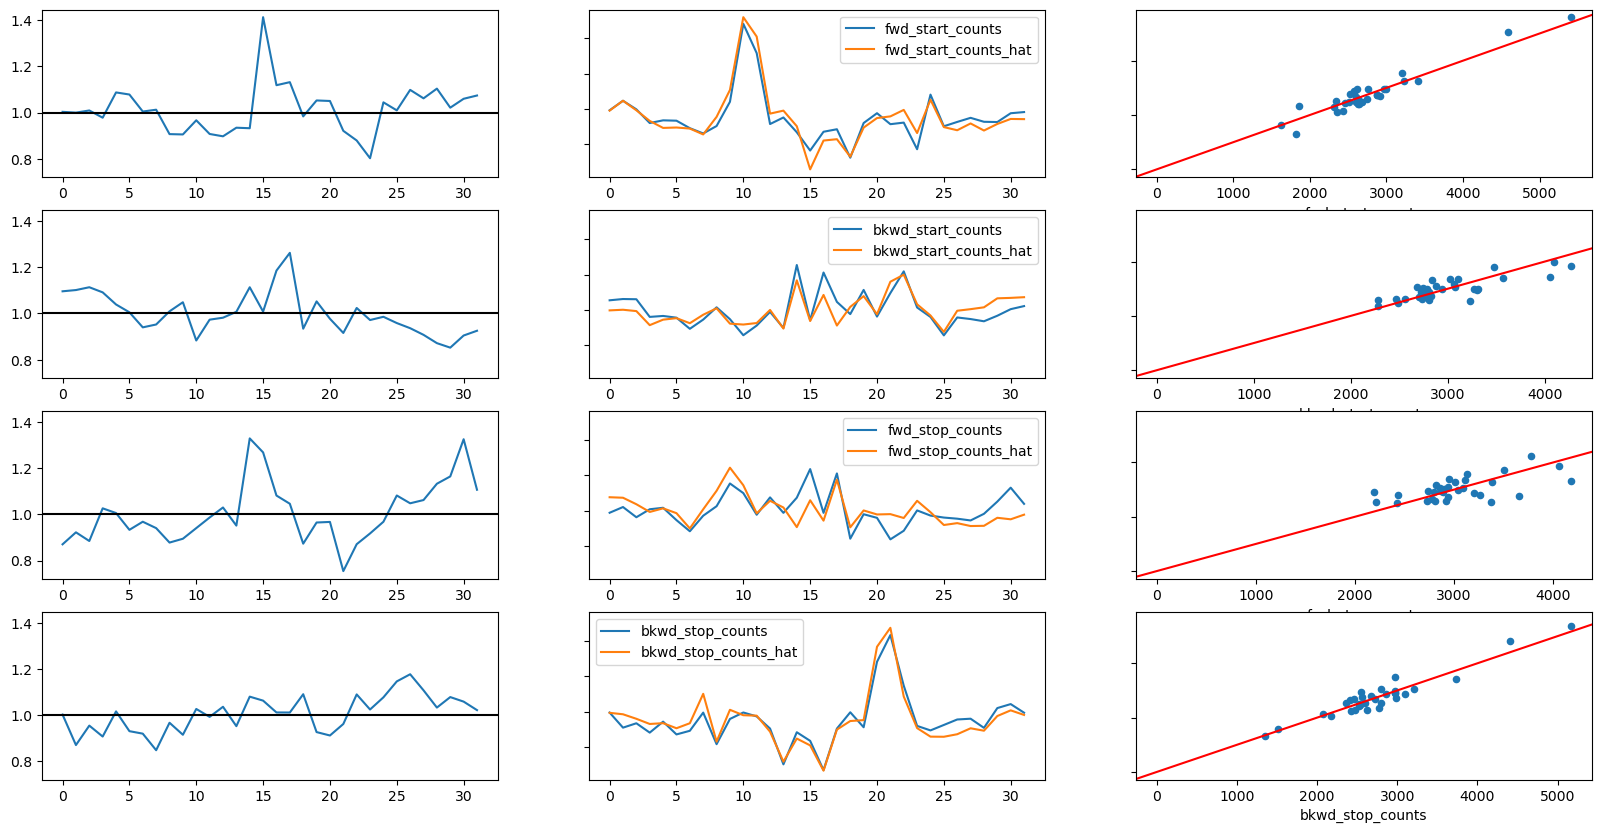

In [185]:
res.plot_summary()

In [194]:
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays
GENE_NAME = 'FAM83E'
sub_df = srdf.query("gene_name == @GENE_NAME")
merged_fa = merge_fragment_arrays([fa for fa in sub_df.fragment_array.tolist()])
merged_fa.region, merged_fa.n_fragments

(Region(chr19:-:48599102-48615486), 29317)

In [195]:
columns = "fwd_start_counts_hat 	bkwd_start_counts_hat 	fwd_stop_counts_hat 	bkwd_stop_counts_hat".split()
def predict_from_seq(self, seq):
    one_hot_seq = one_hot_encode_sequences([seq.encode(),])[0, :, :].T
    one_hot_seq = torch.Tensor(one_hot_seq)[None, :].cuda()
    return pd.DataFrame(softmax(self.model(one_hot_seq).cpu().detach().numpy()[0].squeeze().astype("float64"), axis=1)).T.rename(columns=dict(zip(range(4), columns)))

In [207]:
merged_fa.region.resize(new_model.calc_input_region_size(merged_fa.length)).start - merged_fa.region.start, merged_fa.region.resize(new_model.calc_input_region_size(merged_fa.length)).stop - merged_fa.region.stop

(-2016, 2016)

In [209]:
new_model.calc_input_region_size(merged_fa.length), merged_fa.length, new_model.calc_input_region_size(merged_fa.length) - merged_fa.length

(20416, 16384, 4032)

In [196]:
with pysam.Fastafile(FASTA_PATH) as fasta:
    pred = predict_from_seq(new_model, merged_fa.region.resize(new_model.calc_input_region_size(merged_fa.length)).get_sequence(fasta).decode())

WARNING	2024-03-24 08:05:00,180	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "



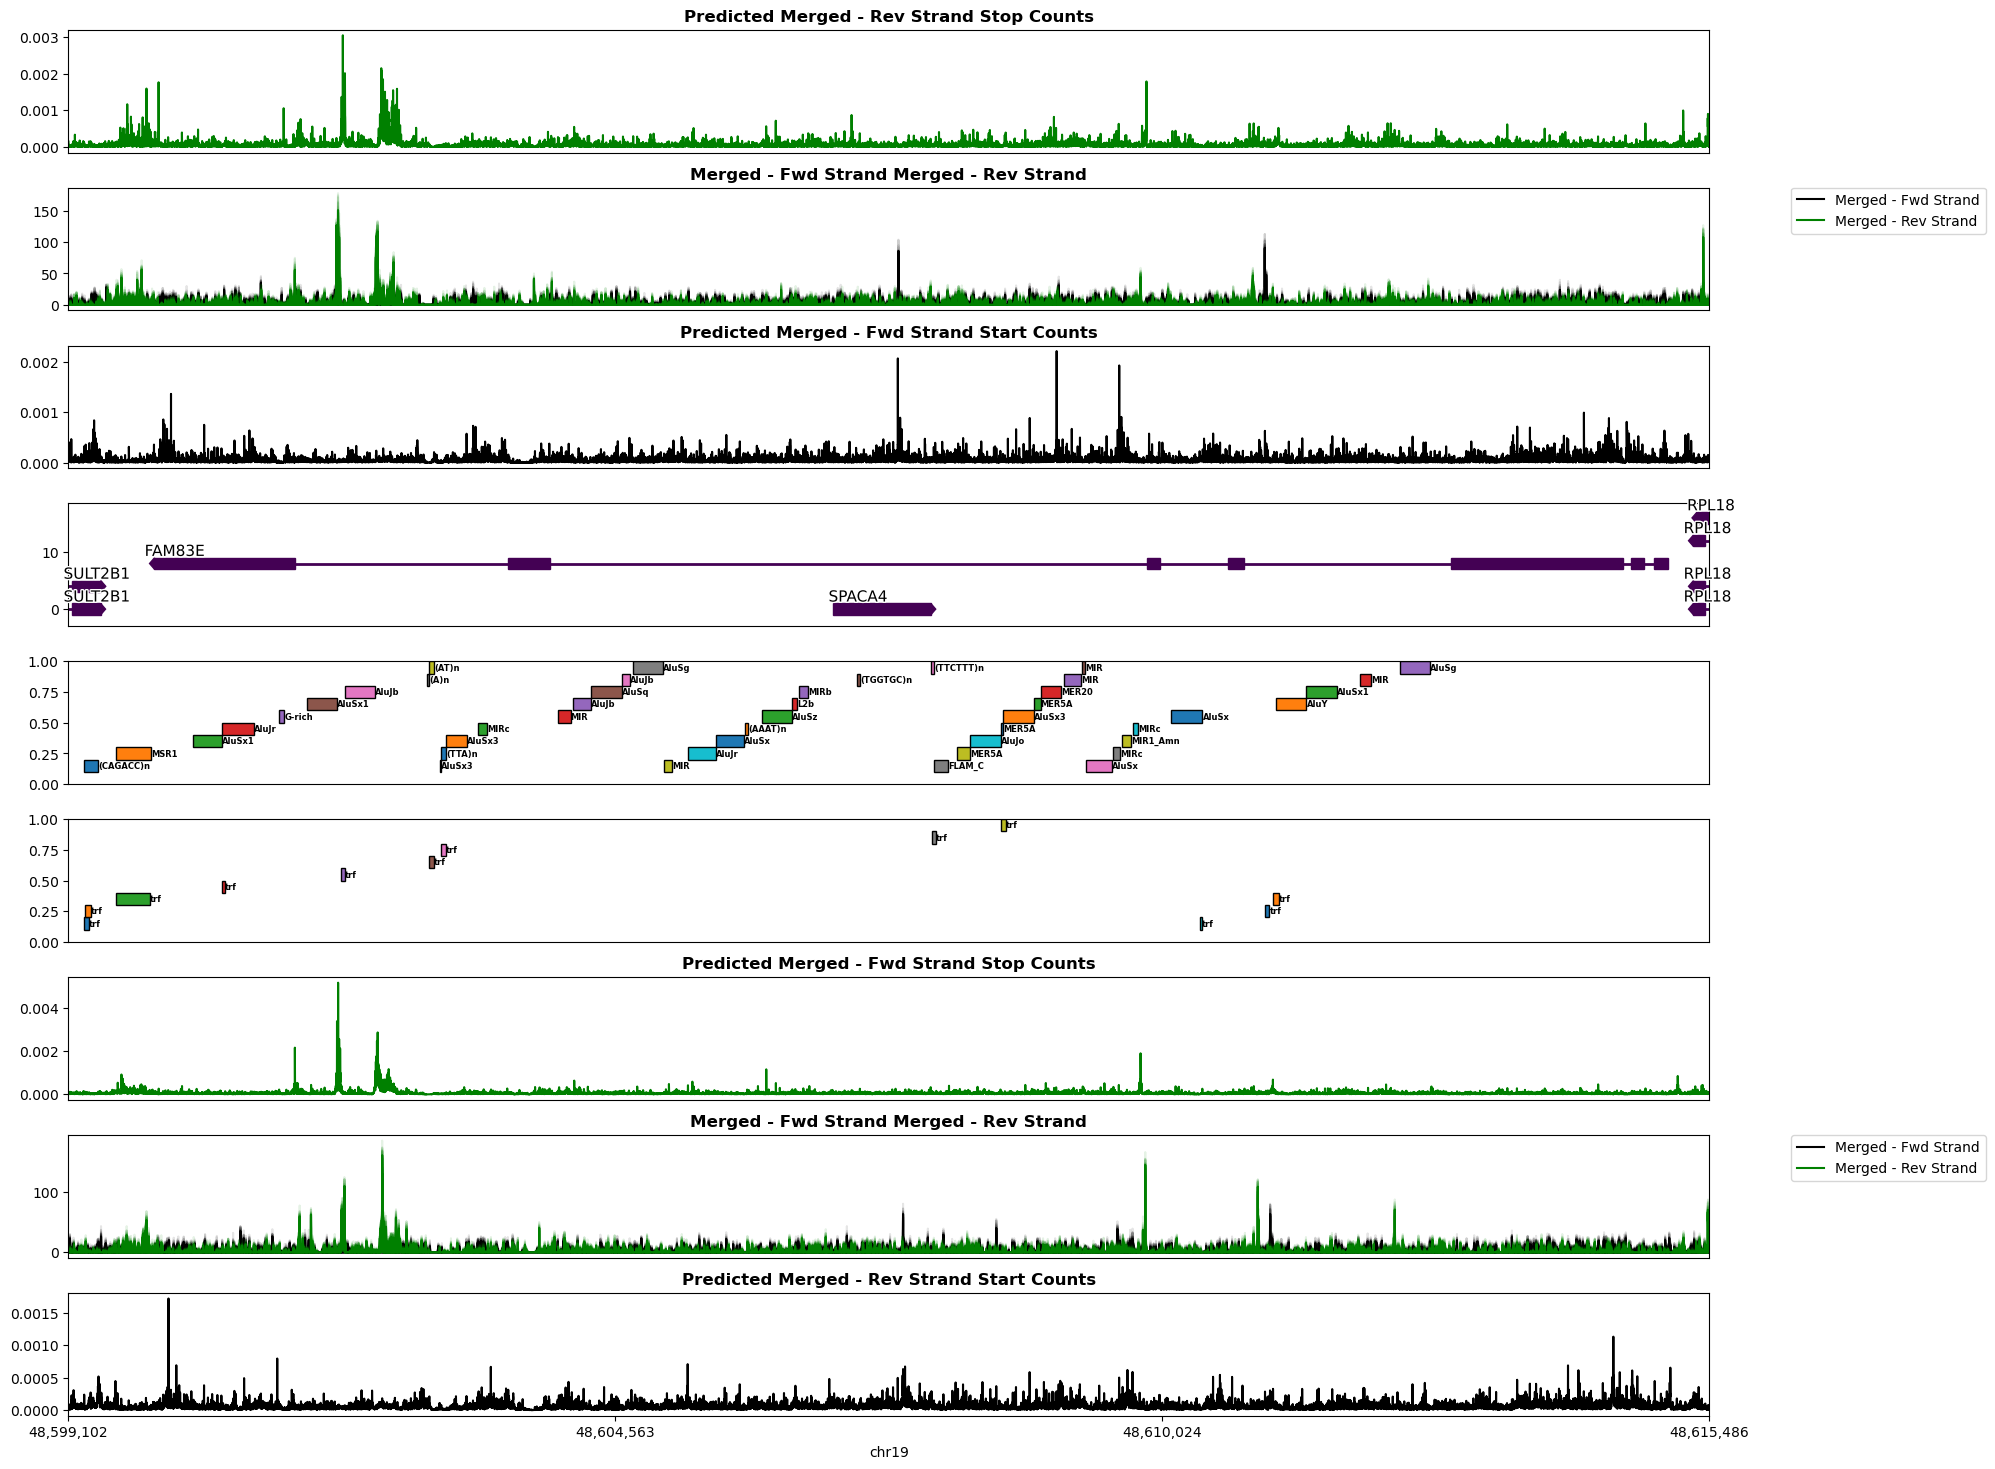

In [197]:
from fragmentomics_tools.plot.tracks import Tracks, StrandSplitCoverageTrack, VectorTrack, GeneTrack, BedTrack
tracks = Tracks()
tracks.append(VectorTrack(pred.bkwd_stop_counts_hat.values, merged_fa.region, name="Predicted Merged - Rev Strand Stop Counts", color='green'))
tracks.append(StrandSplitCoverageTrack(merged_fa, merged_fa.region, coverage_type='left_endpoint', smooth_window=None, fraction=(40, 400), name="Merged"))
tracks.append(VectorTrack(pred.fwd_start_counts_hat.values, merged_fa.region, name="Predicted Merged - Fwd Strand Start Counts", color='black'))

tracks.append(GeneTrack("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz", merged_fa.region))
tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", merged_fa.region))
tracks.append(BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", merged_fa.region))

tracks.append(VectorTrack(pred.bkwd_start_counts_hat.values, merged_fa.region, name="Predicted Merged - Fwd Strand Stop Counts", color='green'))
tracks.append(StrandSplitCoverageTrack(merged_fa, merged_fa.region, coverage_type='right_endpoint', smooth_window=None, fraction=(40, 400), name="Merged"))
tracks.append(VectorTrack(pred.fwd_stop_counts_hat.values, merged_fa.region, name="Predicted Merged - Rev Strand Start Counts", color='black'))
#for record in sub_df.sample(5).itertuples():
#    tracks.append(StrandSplitCoverageTrack(record.fragment_array, record.fragment_array.region, fraction=(40, 60), name=f"{record.sample_id} - {record.ENDO_CATEGORY}"))
fig, axs = tracks.plot()

# Spike-in Analysis 

In [18]:
name = "SPARK-175-3a-v1"

In [19]:
fa = pysam.Fastafile("/scratch/karius/short_read_mapping/spikein.fa")
# reads = pysam.AlignmentFile("/scratch/karius/short_read_mapping/bowtie/mappped.sorted.bam")
reads = pysam.AlignmentFile("/scratch/karius/short_read_mapping/RD-56170-Lib1_NC-14151/mappped.sorted.bam")
ref_df = pd.DataFrame(dict(ref=fa.references, len=fa.lengths)).query("len >= 50 and not ref.str.startswith('ID')").sort_values('len')

In [21]:
def build_train_srdf():
    train_rdf = RegionDataFrame(
        pandas.read_table("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed"), ref='hg38') \
        .resize_regions(2048)
    train_rdf['strand'] = None
    train_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(train_rdf, load_ibd_sample_df().head(1))
    return train_srdf
train_srdf = build_train_srdf().sample(10000)

WARNING	2024-03-22 18:29:58,223	/tmp/ipykernel_2329921/2749017376.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  pandas.read_table("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed"), ref='hg38') \



In [22]:
val_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(ctcf_rdf.resize_regions(64), load_ibd_sample_df().head(1)).sample(1000)

In [23]:
test_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(ctcf_rdf.resize_regions(32), load_ibd_sample_df().head(1))

In [23]:
model = BackgroundModel(residual_layers=1)

In [24]:
model.train(train_srdf, val_srdf)

Calculated size: 2108


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:04<00:00, 2120.08it/s]


Calculated size: 124


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1367.40it/s]
WARNING	2024-03-22 15:01:20,814	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-

[1,  1000] loss: 177.178
[1,  2000] loss: 178.266
[1,  3000] loss: 174.914
[1,  4000] loss: 176.408
[1,  5000] loss: 174.734
[1,  6000] loss: 175.580
[1,  7000] loss: 175.747
[1,  8000] loss: 175.327
[1,  9000] loss: 178.476
[1, 10000] loss: 176.524
Test Lhd: -1951.8264177138299
[2,  1000] loss: 173.011
[2,  2000] loss: 172.187
[2,  3000] loss: 175.778
[2,  4000] loss: 175.698
[2,  5000] loss: 173.080
[2,  6000] loss: 176.233
[2,  7000] loss: 174.620
[2,  8000] loss: 174.551
[2,  9000] loss: 173.856
[2, 10000] loss: 176.625
Test Lhd: -1895.7877287510455
[3,  1000] loss: 175.157
[3,  2000] loss: 173.229
[3,  3000] loss: 171.076
[3,  4000] loss: 173.361
[3,  5000] loss: 171.869
[3,  6000] loss: 178.778
[3,  7000] loss: 174.615
[3,  8000] loss: 174.551
[3,  9000] loss: 172.690
[3, 10000] loss: 174.524
Test Lhd: -1923.9677451022071
[4,  1000] loss: 172.200
[4,  2000] loss: 175.008
[4,  3000] loss: 171.637
[4,  4000] loss: 173.073
[4,  5000] loss: 172.418
[4,  6000] loss: 174.759
[4,  7000]

In [25]:
res = model.predict_aggregate(test_srdf)

Calculated size: 92


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48037/48037 [00:19<00:00, 2461.40it/s]


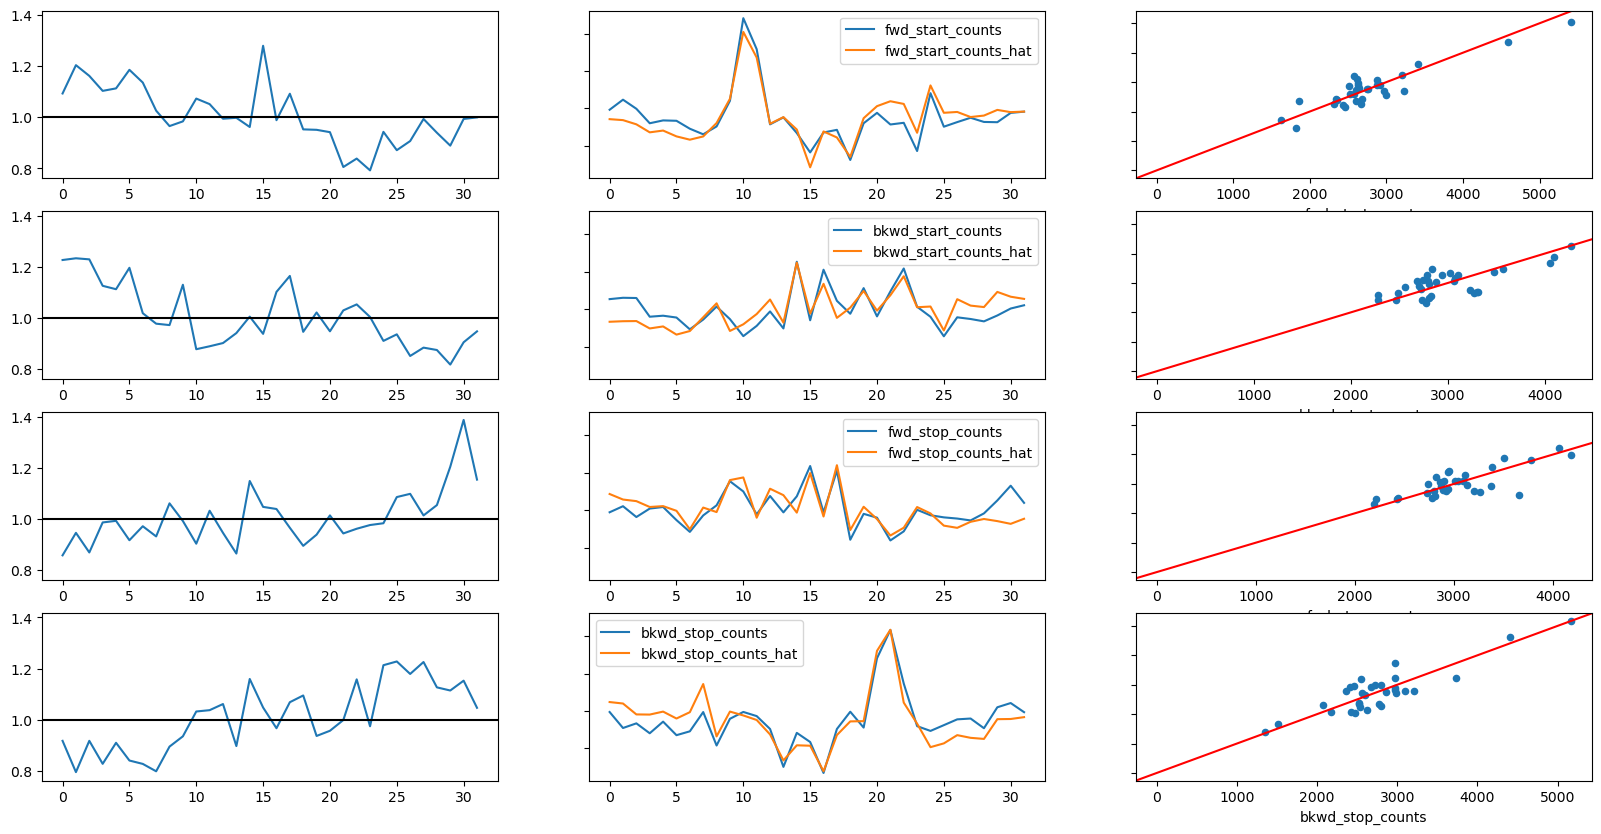

In [26]:
res.plot_summary()

In [27]:
fa = pysam.Fastafile("/scratch/karius/short_read_mapping/spikein.fa")
# reads = pysam.AlignmentFile("/scratch/karius/short_read_mapping/bowtie/mappped.sorted.bam")
reads = pysam.AlignmentFile("/scratch/karius/short_read_mapping/RD-56170-Lib1_NC-14151/mappped.sorted.bam")
ref_df = pd.DataFrame(dict(ref=fa.references, len=fa.lengths)).query("len >= 50 and not ref.str.startswith('ID')").sort_values('len')

In [28]:
ref_df

,ref,len
314,RNA_Oligo_1,50
315,RNA_Oligo_2,50
14,SPARK-052-20GC-01-v1,52
46,SPARK-SLAP-RE,52
50,spark-052,52
...,...,...
360,v4-175-50-ss-01,175
55,spark-175,175
35,SPARK-175-3b-v1,175
56,spark-350,350


In [59]:
def predict_from_seq(self, seq):
    one_hot_seq = one_hot_encode_sequences([seq.encode(),])[0, :, :].T
    one_hot_seq = torch.Tensor(one_hot_seq)[None, :].cuda()
    return pd.DataFrame(softmax(self.model(one_hot_seq).cpu().detach().numpy()[0].squeeze().astype("float64"), axis=1)).T

In [33]:
from fragments_h5.fragment import bam_to_fragments
def make_cov(contig):
    seq = fa.fetch(contig)
    start_cov = {'+': np.zeros(len(seq)), '-': np.zeros(len(seq))}
    stop_cov = {'+': np.zeros(len(seq)), '-': np.zeros(len(seq))}
    for x in bam_to_fragments(reads, chrom=contig, min_mapq=10):
        if x.length < 20:
            continue
        start_cov[x.strand][x.start] += 1
        stop_cov[x.strand][x.stop-1] += 1
    cov = pd.DataFrame(dict(plus_strand_starts=start_cov['+'], minus_strand_starts=start_cov['-'], plus_strand_ends=stop_cov['+'], minus_strand_ends=stop_cov['-']))
    cov = cov.iloc[15:-15, :].reset_index(drop=True)
    return cov

In [34]:
cov = make_cov(name)

In [35]:
cov

,plus_strand_starts,minus_strand_starts,plus_strand_ends,minus_strand_ends
0,432.0,81.0,0.0,0.0
1,68.0,73.0,0.0,0.0
2,544.0,435.0,0.0,0.0
3,704.0,94.0,0.0,0.0
4,232.0,180.0,2.0,7.0
...,...,...,...,...
140,4.0,0.0,385.0,431.0
141,0.0,0.0,77.0,692.0
142,0.0,0.0,238.0,93.0
143,0.0,0.0,620.0,1148.0


In [58]:
pred = predict_from_seq(model, fa.fetch(name))

NameError: name 'predict_from_seq' is not defined

In [39]:
pred.sum()

0    1.0
1    1.0
2    1.0
3    1.0
dtype: float64

In [40]:
## np.corrcoef(pd.concat([pred, cov], axis=1, ignore_index=False).T).round(2)

(115, 4)

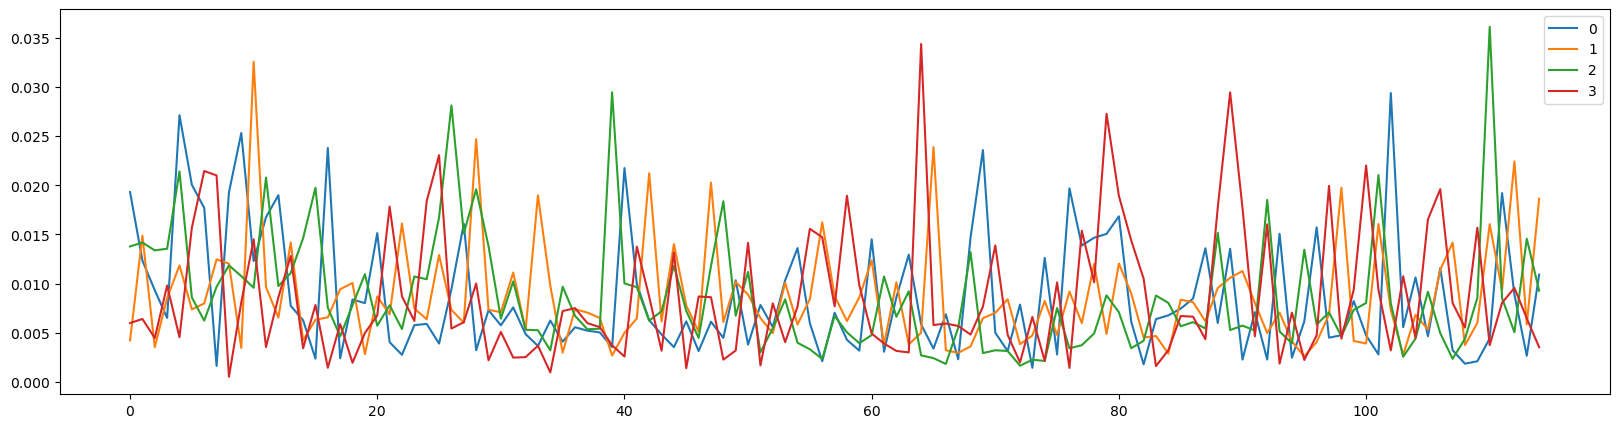

In [41]:
pred.plot(figsize=(20, 5))
pred.shape

(145, 4)

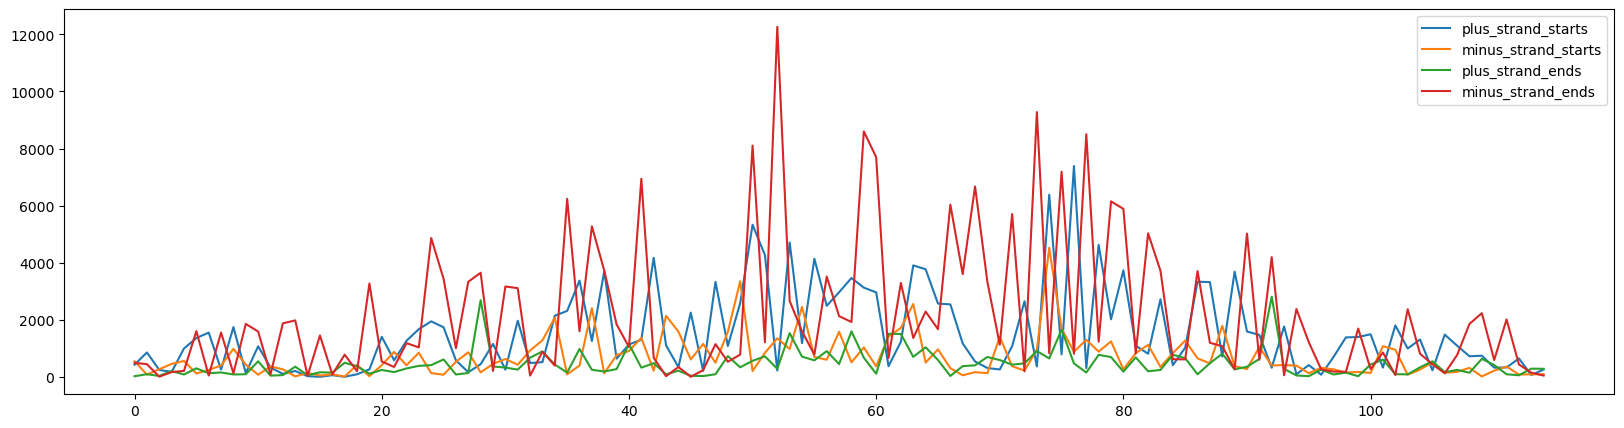

In [42]:
cov[15:-15].reset_index(drop=True).plot(figsize=(20, 5))
cov.shape

<Axes: >

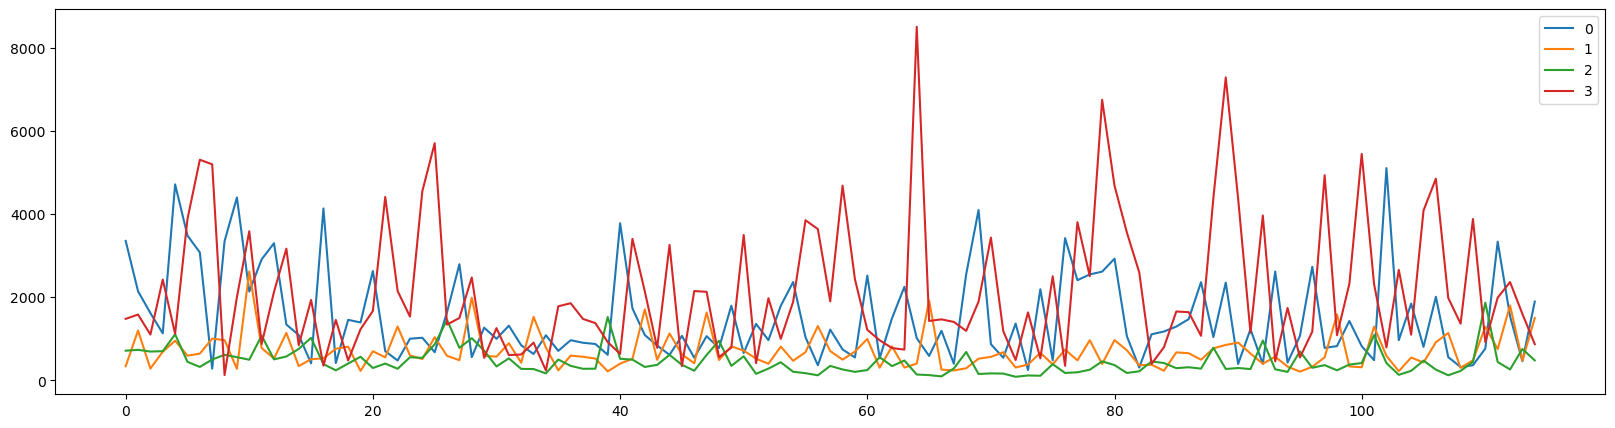

In [43]:
pred.mul(cov.iloc[15:-15, :].sum().values).plot(figsize=(20, 5))

# CTCF Analysis

In [39]:
from fragmentomics_tools.dataframe import SampleAndRegionDataFrame
from lib import load_ibd_sample_df

In [24]:
def build_train_srdf():
    train_rdf = RegionDataFrame(
        pandas.read_table("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed"), ref='hg38') \
        .sample(20000, random_state=314) \
        .resize_regions(2048)
    train_rdf['strand'] = None
    train_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(train_rdf, load_ibd_sample_df().head(1))
    return train_srdf

In [25]:
train_srdf = build_train_srdf().sample(10000)

WARNING	2024-03-23 07:47:54,575	/tmp/ipykernel_2334804/2768408699.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  pandas.read_table("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed"), ref='hg38') \



In [26]:
val_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(ctcf_rdf.resize_regions(64), load_ibd_sample_df().head(1)).sample(1000)

In [285]:
model = BackgroundModel(residual_layers=4)
model.train(train_srdf, val_srdf)

Calcualted size: 2528


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 2509.41it/s]


Calcualted size: 544


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1314.10it/s]
WARNING	2024-03-21 08:42:32,838	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-

[1,  3000] loss: 150.383
Test Lhd: -987.139906731768
[1,  6000] loss: 148.029
Test Lhd: -967.3116799509562
[1,  9000] loss: 149.333
Test Lhd: -920.5306745227763
Test Lhd: -946.6831067221001
Finished Training


In [27]:
test_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(ctcf_rdf.resize_regions(32), load_ibd_sample_df().head(1))

In [287]:
test_srdf.shape

(48037, 24)

In [288]:
res = model.predict_aggregate(test_srdf)

Calcualted size: 512


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48037/48037 [00:20<00:00, 2310.50it/s]


In [289]:
res.sum()

fwd_start_counts         22124.0
fwd_start_counts_hat     22124.0
bkwd_start_counts        24129.0
bkwd_start_counts_hat    24129.0
fwd_stop_counts          24175.0
fwd_stop_counts_hat      24175.0
bkwd_stop_counts         22105.0
bkwd_stop_counts_hat     22105.0
dtype: float64

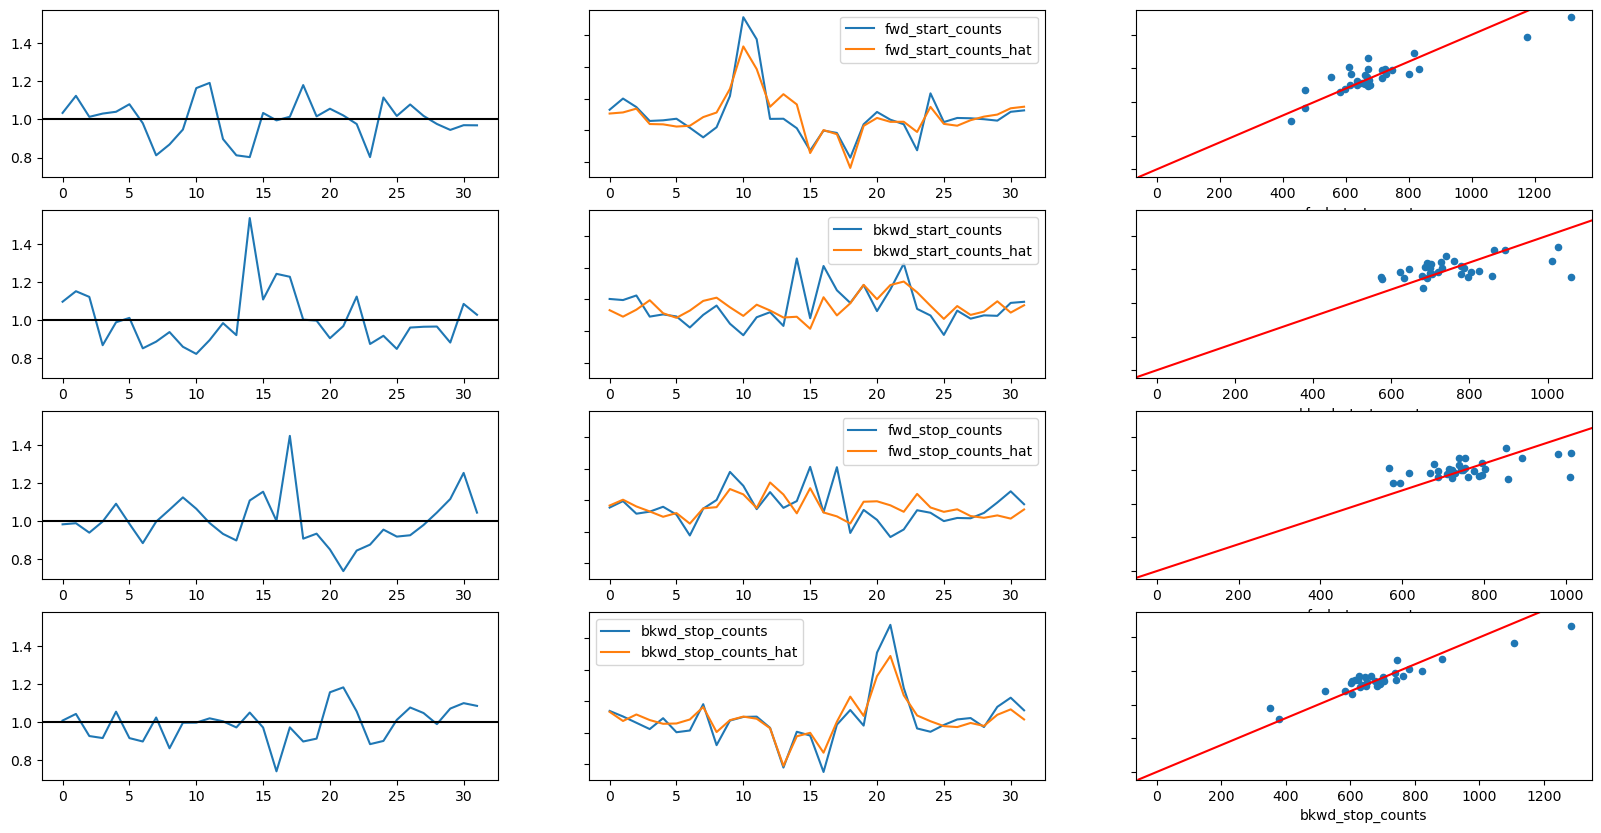

In [290]:
res.plot_summary()